# Warm TDM operations template

A worked, runnable outline of the standard bench workflow using the
`warm_tdm_api.operations` API. It follows the muxed-run bring-up model
(`docs/design/muxed-run-bringup.md`): the three configuration layers are

* **A — enabled set**: which columns/rows participate (`ColTuneEnable`, row map)
* **B — tune point**: the servo setpoints a tune produces (SA/SQ1 bias & fb, ...)
* **C — run settings**: how the muxed run is clocked/servoed (`setup_mux`)

**A is the anchor** — set it first; tuning (B) is performed against it, and the
run settings (C) are expressed over it. This template is source-controlled as a
percent-format `.py` (clean diffs); a generated `.ipynb` sits next to it.

Edit the marked values for your hardware. Cells run top to bottom.

## 0. Connect

`ops.connect()` builds a client to the running `warmTdmServer` and caches a
default `Session`, so the free-function shims (`ops.take_raw(...)`, etc.)
work without a `session.` prefix. Scripts/tests should instead hold an explicit
`Session` (`sess = ops.connect(...)`) and call methods on it.

In [1]:
%run ../scripts/_setupLibPaths.py
%matplotlib inline

import warm_tdm_api.operations as ops

sess = ops.connect(host="localhost", port=9099)   # returns the default Session
ops.status()                                       # one-shot state summary
ops.print_hardware()                               # firmware/build info per board

Connected to GroupRoot at localhost:9099
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Session status
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Column boards      : [0]
  Row boards         : [0]
  Channels/board     : 8
  Timing run state   : stopped
  Timing mode        : manual
  Tune-enabled cols  : [0, 1, 2, 3]
  Output dir         : /sdf/group/faders/users/bareese/projects/warm-tdm-cleanup/software/data/20260911/1789164423
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Hardware Information
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Column Board 0:
  BuildStamp       : ColumnFpgaBoard325Coord10G: Vivado v2024.1, rdsrv419 (Ubuntu 22.04.5 LTS), Built Fri Sep 11 11:47:02 AM PDT 2026 by bareese
  DeviceDna        : 0x8b4c167d5e854
  Git hash         : 0x1045236eecac9719092883b78dee6e850c63698b
  Image Name       : Colu

Optional one-time analog setup (front-end dependent — set for your cryostat):

In [2]:
ops.set_cryo_resistance(Rcryo_Ohm=116.0)         # roundtrip cable R on all AFE amps
ops.set_ps_synch(1)                              # synchronize board power supplies
ops.disable_leds()

Set cryostat resistance to 116.0 Ohm.
Synchronized power supplies.
Disabled LEDs on all boards.


## A. Enabled set (the anchor)

Choose which columns and rows are read out **before** tuning. Everything below
is indexed against this. `ColTuneEnable` is a per-column bool list;
`RowIndexOrderList` is the logical readout order (see docs/design/row-mapping.md).

In [3]:
r = sess.root                                       # the pyrogue tree (client mirror)
group = sess.group

group.ColTuneEnable.set([1,1,1,1,0,0,0,0])                 # <-- which columns participate
group.RowMap6x10()                                  # <-- pick a row map for your array
group.RowIndexOrderList.set([10, 11, 12, 13])           # <-- logical rows to read out

print("cols enabled:", group.ColTuneEnable.get())
print("row order    :", group.RowIndexOrderList.get())

cols enabled: [1, 1, 1, 1, 0, 0, 0, 0]
row order    : [10 11 12 13]


## B. Tune point

Tune in stages against the enabled set. Each wrapper starts the corresponding
`pr.Process`, blocks until it finishes, and returns its output. Zero the
setpoints first for repeatability across tunes.

In [4]:
import numpy as np

ncol = len(group.ColTuneEnable.get())
group.Sq1FbForceCurrent.set([0.0] * ncol)
group.Sq1BiasForceCurrent.set([0.0] * ncol)
group.SaFbForceCurrent.set([0.0] * ncol)

### B.1 SA offset + SA tune

In [5]:
#ops.sa_offset()                                     # PID the SA offset to null SA bias

sa_out = ops.sa_tune(                               # sweep SA bias/fb, pick lock points
    SaFbLowOffset = 0.0,
    SaFbHighOffset = 100.0,
    SaFbNumSteps = 300,
    SaBiasLowOffset=47.4,
    SaBiasHighOffset=50.0,
    SaBiasNumSteps=1,
    SetAfterFinish=True,
)

SaTuneProcess: Done


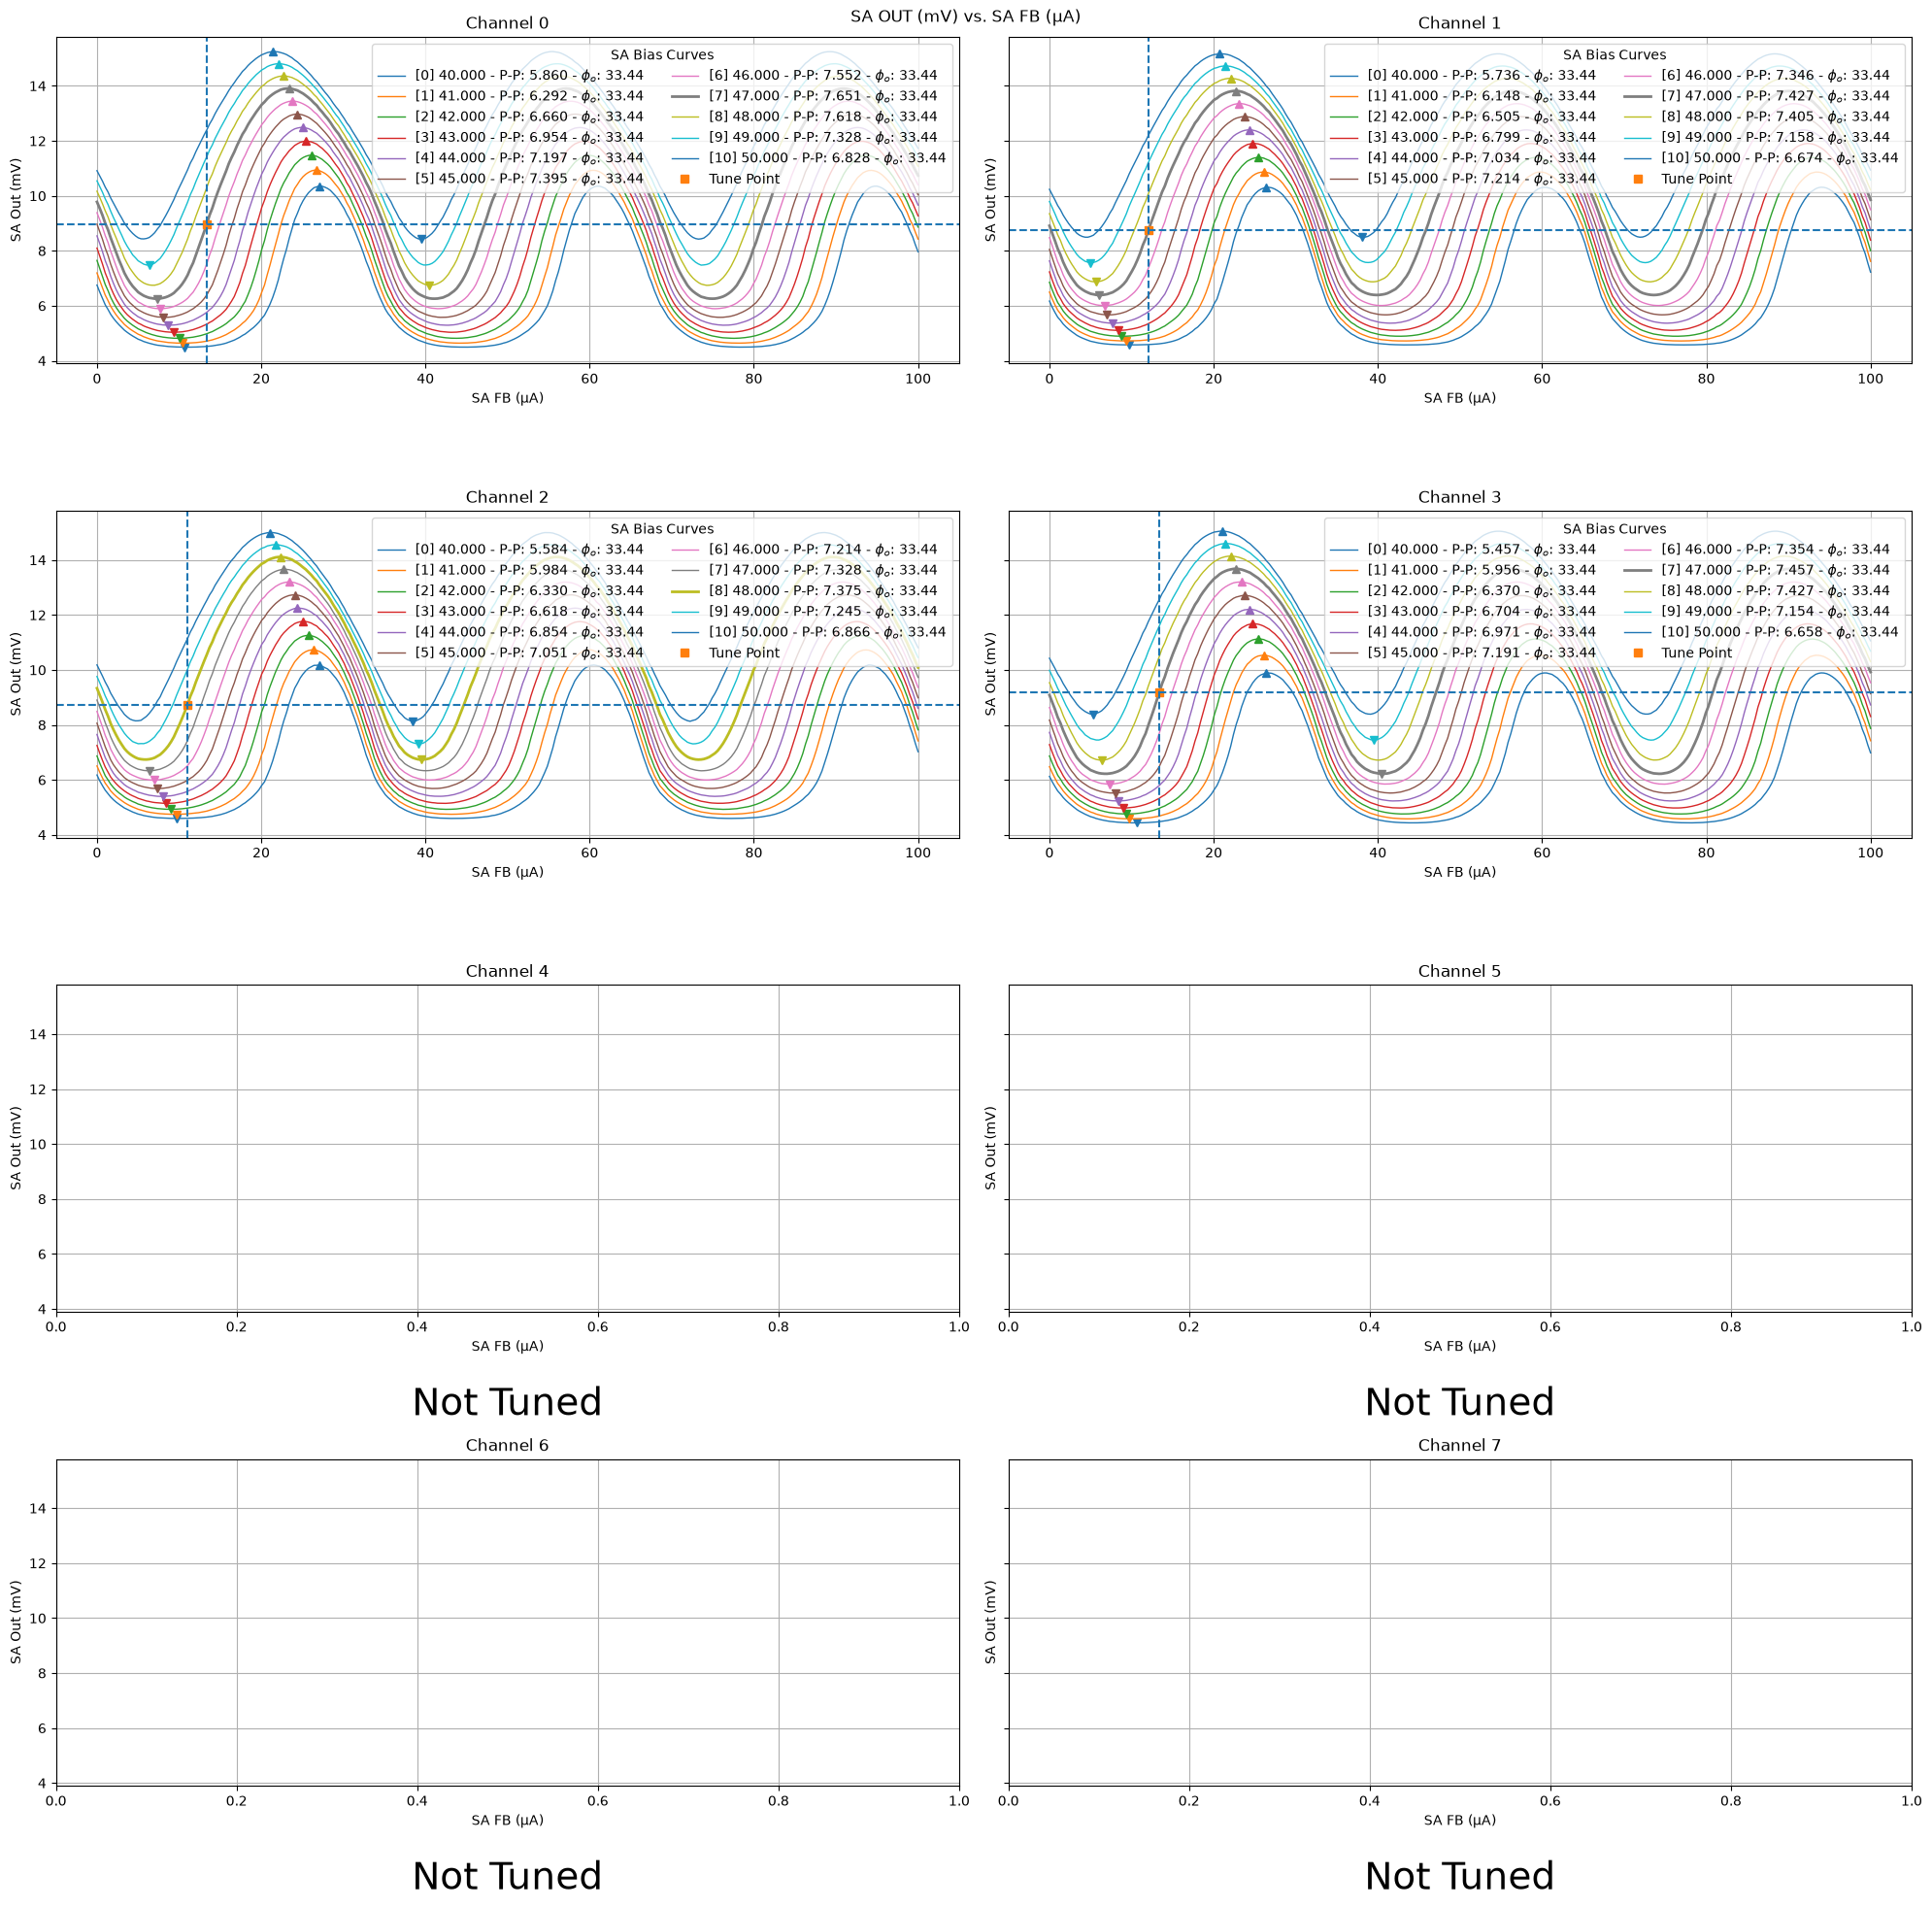

In [7]:
# ops.sa_tune sets the tune result on the tree (SetAfterFinish). Inspect via the
# process node's plots if desired, e.g. 
group.SaTuneProcess.MultiPlot.get()

### B.2 FAS tune

`fas_tune` sweeps each active logical row's physical FAS line (via the row DAC
driver's `ManualSet`, timing stopped) and servos SA feedback to pick that row's
FAS-on current. It reuses the SA-tuned `SaFbCurrent` and applies a temporary
bootstrap SQ1 bias so the FAS response is observable before SQ1 is tuned,
restoring the prior SQ1 bias/fb afterward. Run it after SA tune and before SQ1
tune. `SetAfterFinish=True` programs the fitted `FasOn` currents onto the row
DAC; the default only returns the candidates.

In [12]:
import scipy.constants as sc

# Calculate the magnetic flux quantum
magnetic_flux_quantum = sc.h / (2 * sc.e)
# from NIST mux21_s4 numbers from NIST (2-level!)
Mfas_Henry = 6.3e-12
fas_phi0_uA = 1.e6*magnetic_flux_quantum/Mfas_Henry
print(f'FAS Phi0 = {fas_phi0_uA:.1f} uA')


rdd = group.HardwareGroup.RowBoard[0].RowDacDriver
rdd.Mode.setDisp("MANUAL") #Set row board to manual mode, to set each of the values individually
i_fas = fas_phi0_uA/2.

for rs in range(10):
    rdd.FasOn.Current_[rs].set(i_fas) # set ON value for raw RS x and drive to DAC
    rdd.FasOff.Current_[rs].set(0) # Set OFF value for RS x (drive 0 to dac to turn it off).[1:13 PM]

for cs in range(10,17):
    rdd.FasOn.Current_[cs].set(i_fas) # set ON value for raw CS x and drive to DAC
    rdd.FasOff.Current_[cs].set(0) # Set OFF value for CS x (drive 0 to dac to turn it off).

FAS Phi0 = 328.2 uA


In [ ]:
fas_out = ops.fas_tune(
    FasFluxHighOffset=310.0,   # <-- span >= one row-select flux period for your array
    FasFluxNumSteps=21,
    Sq1BiasCurrent=40.0,       # temporary bootstrap SQ1 bias during the sweep
    SetAfterFinish=True,       # program the fitted FasOn currents onto the row DAC
)
# Each entry in fas_out carries its selected `fasOn` and swept response curve;
# inspect group.FasTuneProcess.SweepPlot / .TunePlot for the per-row sweeps.

### B.3 SQ1 tune

Run after FAS tune, which has set the row-select FAS-on currents that select
each row for the SQ1 sweep.

In [ ]:
sq1_out = ops.sq1_tune(
    Sq1FbLowOffset=-30.0,
    Sq1FbHighOffset = 30.0,
    Sq1FbNumSteps = 120,
    Sq1BiasLowOffset = 50.0,
    Sq1BiasHighOffset = 50.0,
    Sq1BiasNumSteps = 1,
    ServoPrecision=0.0015,
    ServoKp=-6.4,
    ServoKi=-0.2,
)

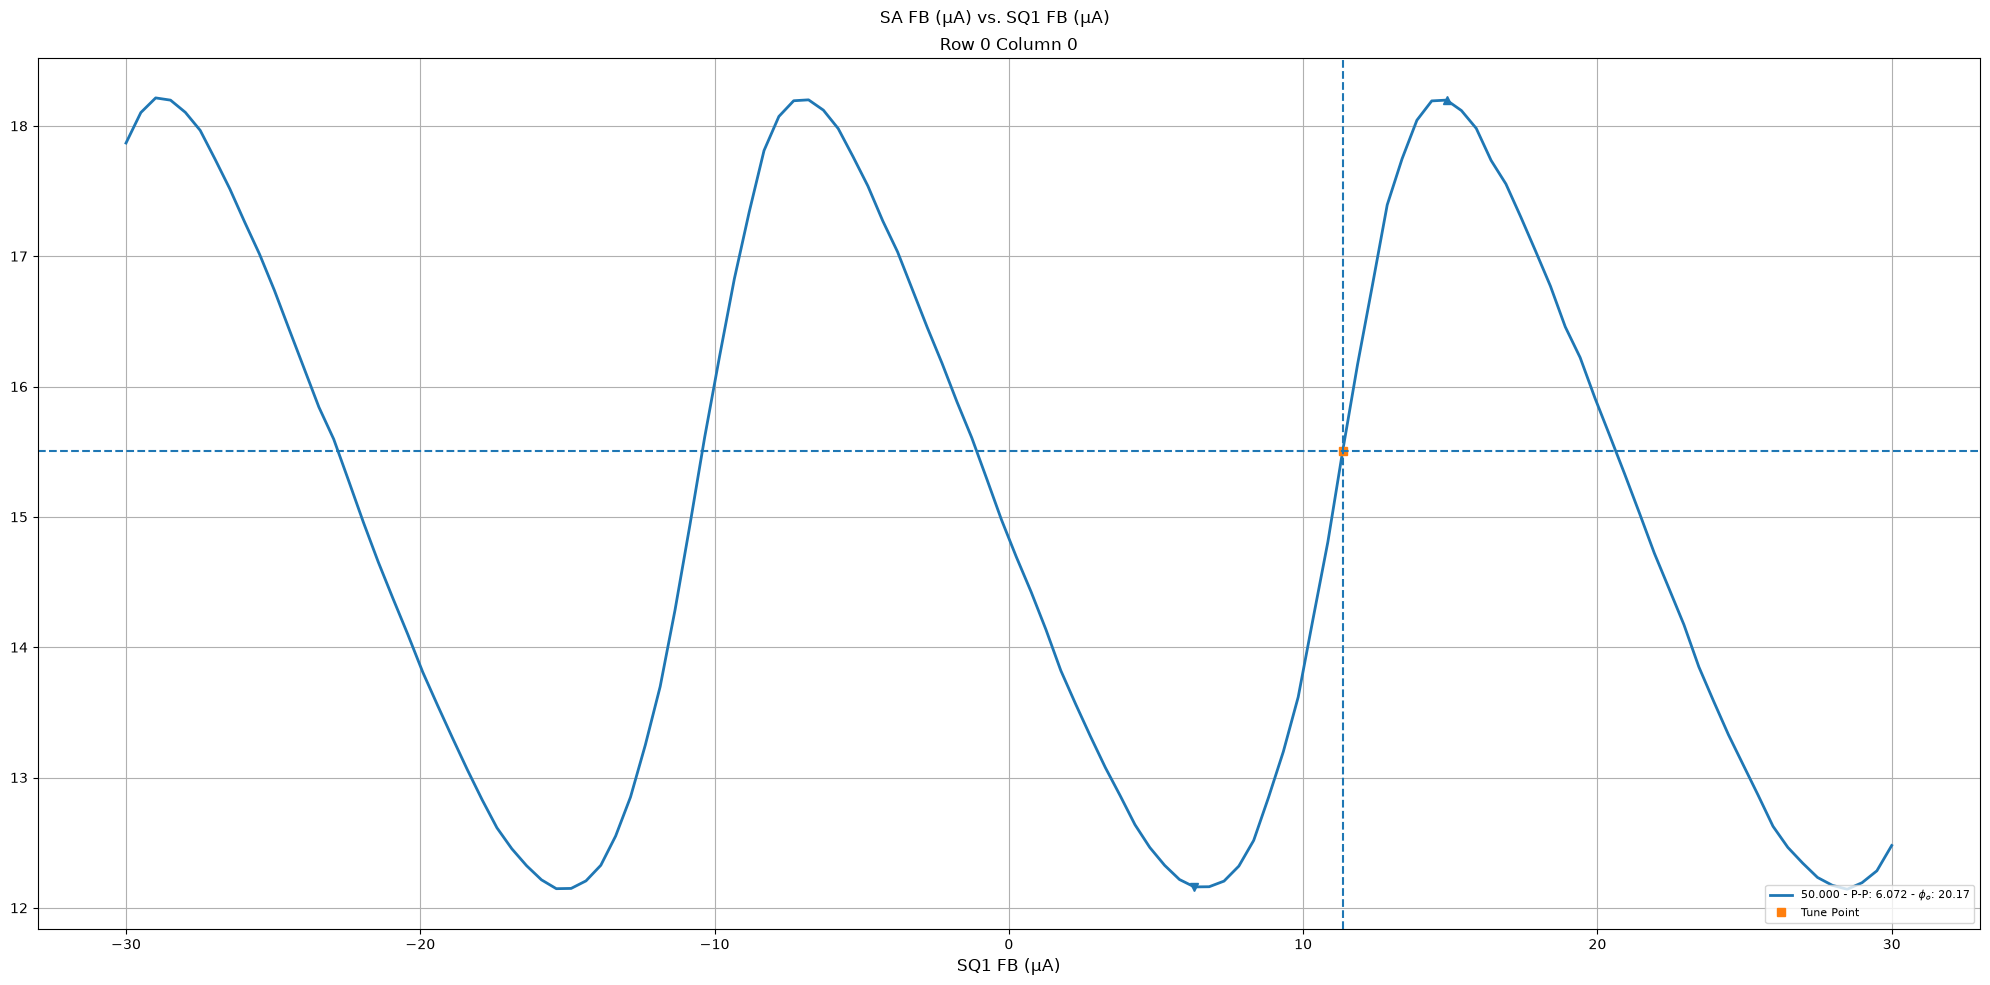

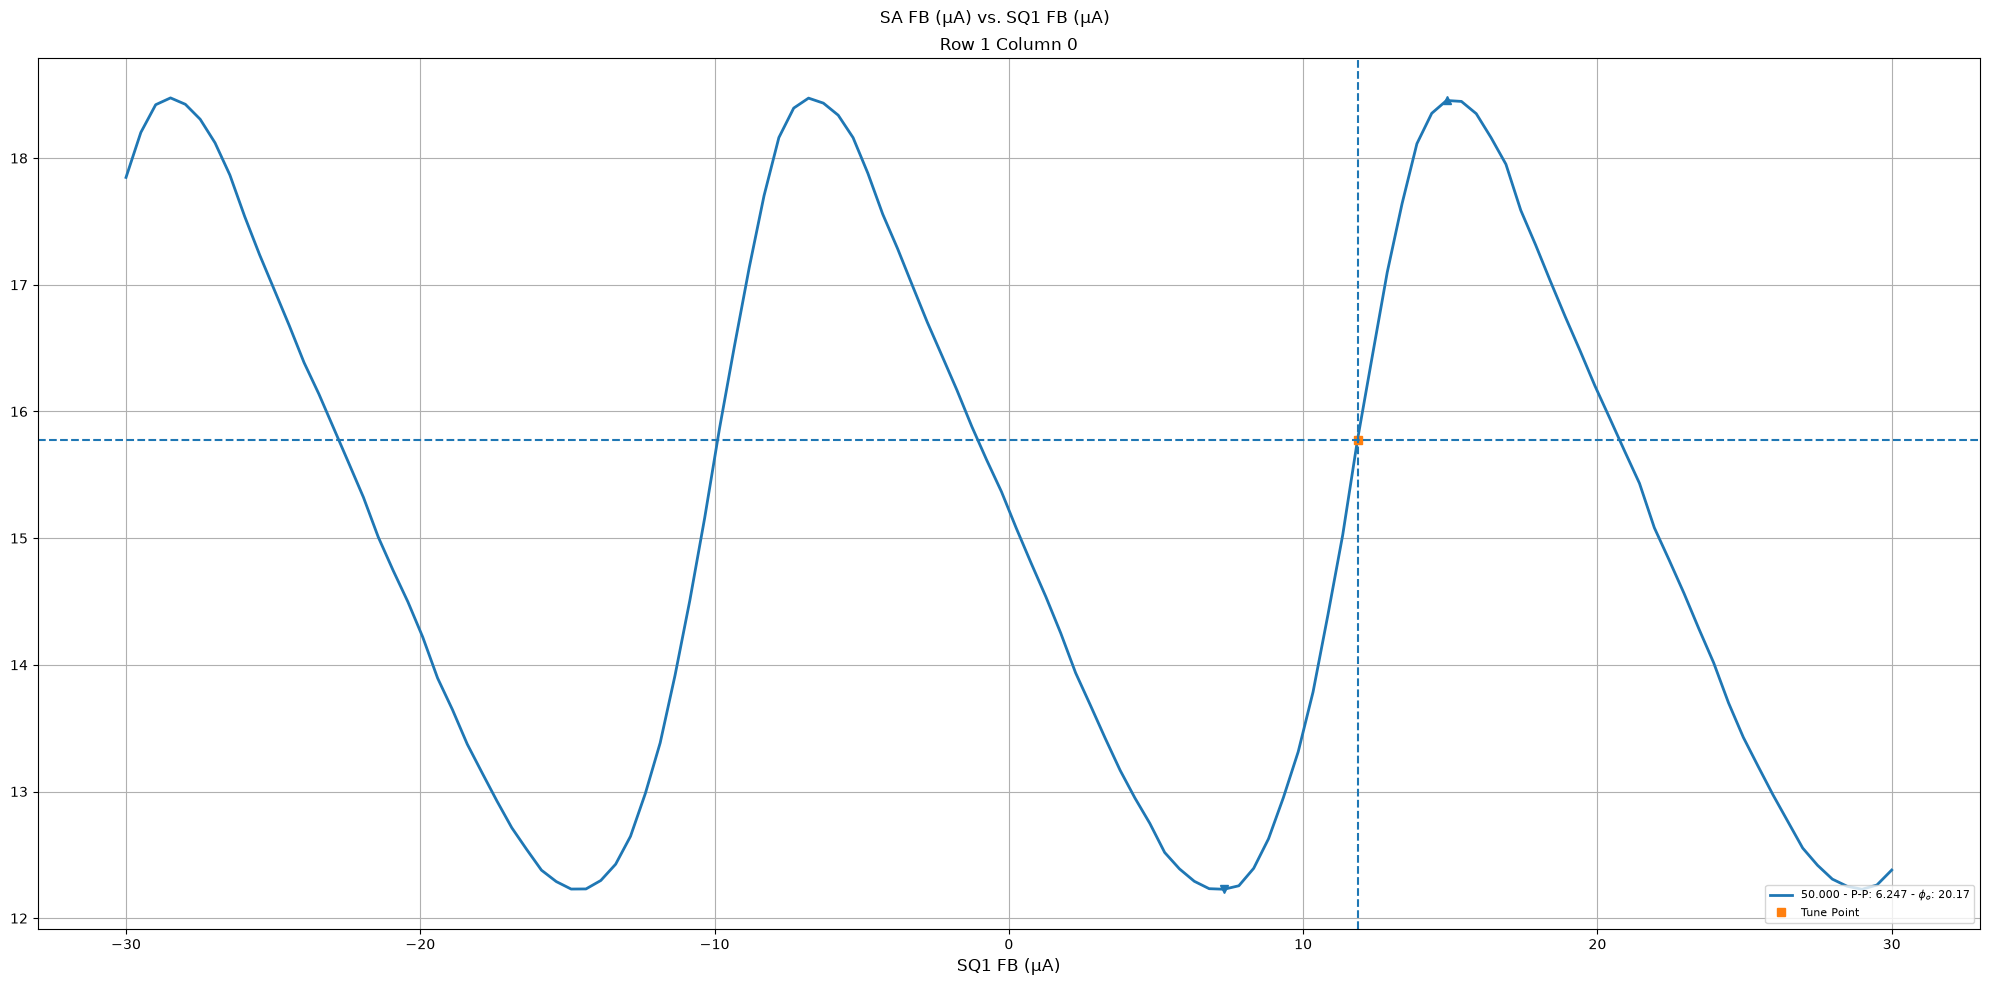

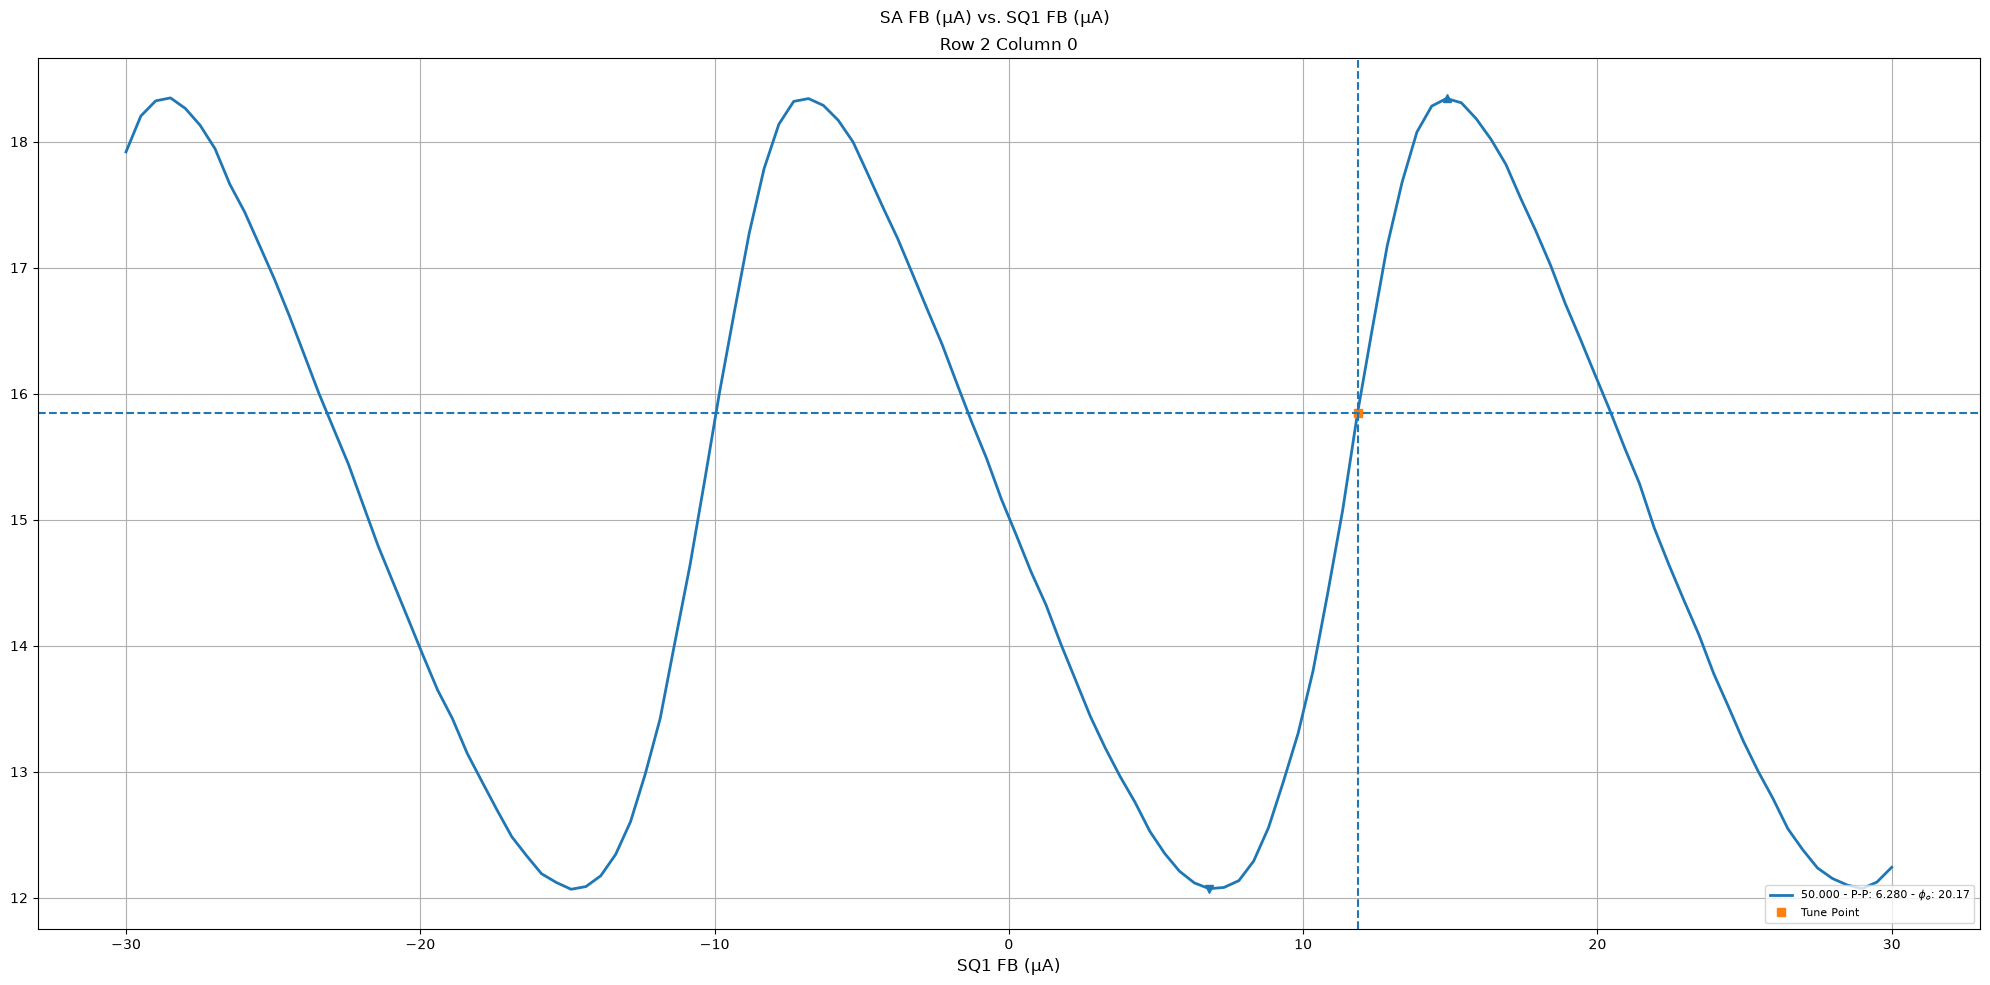

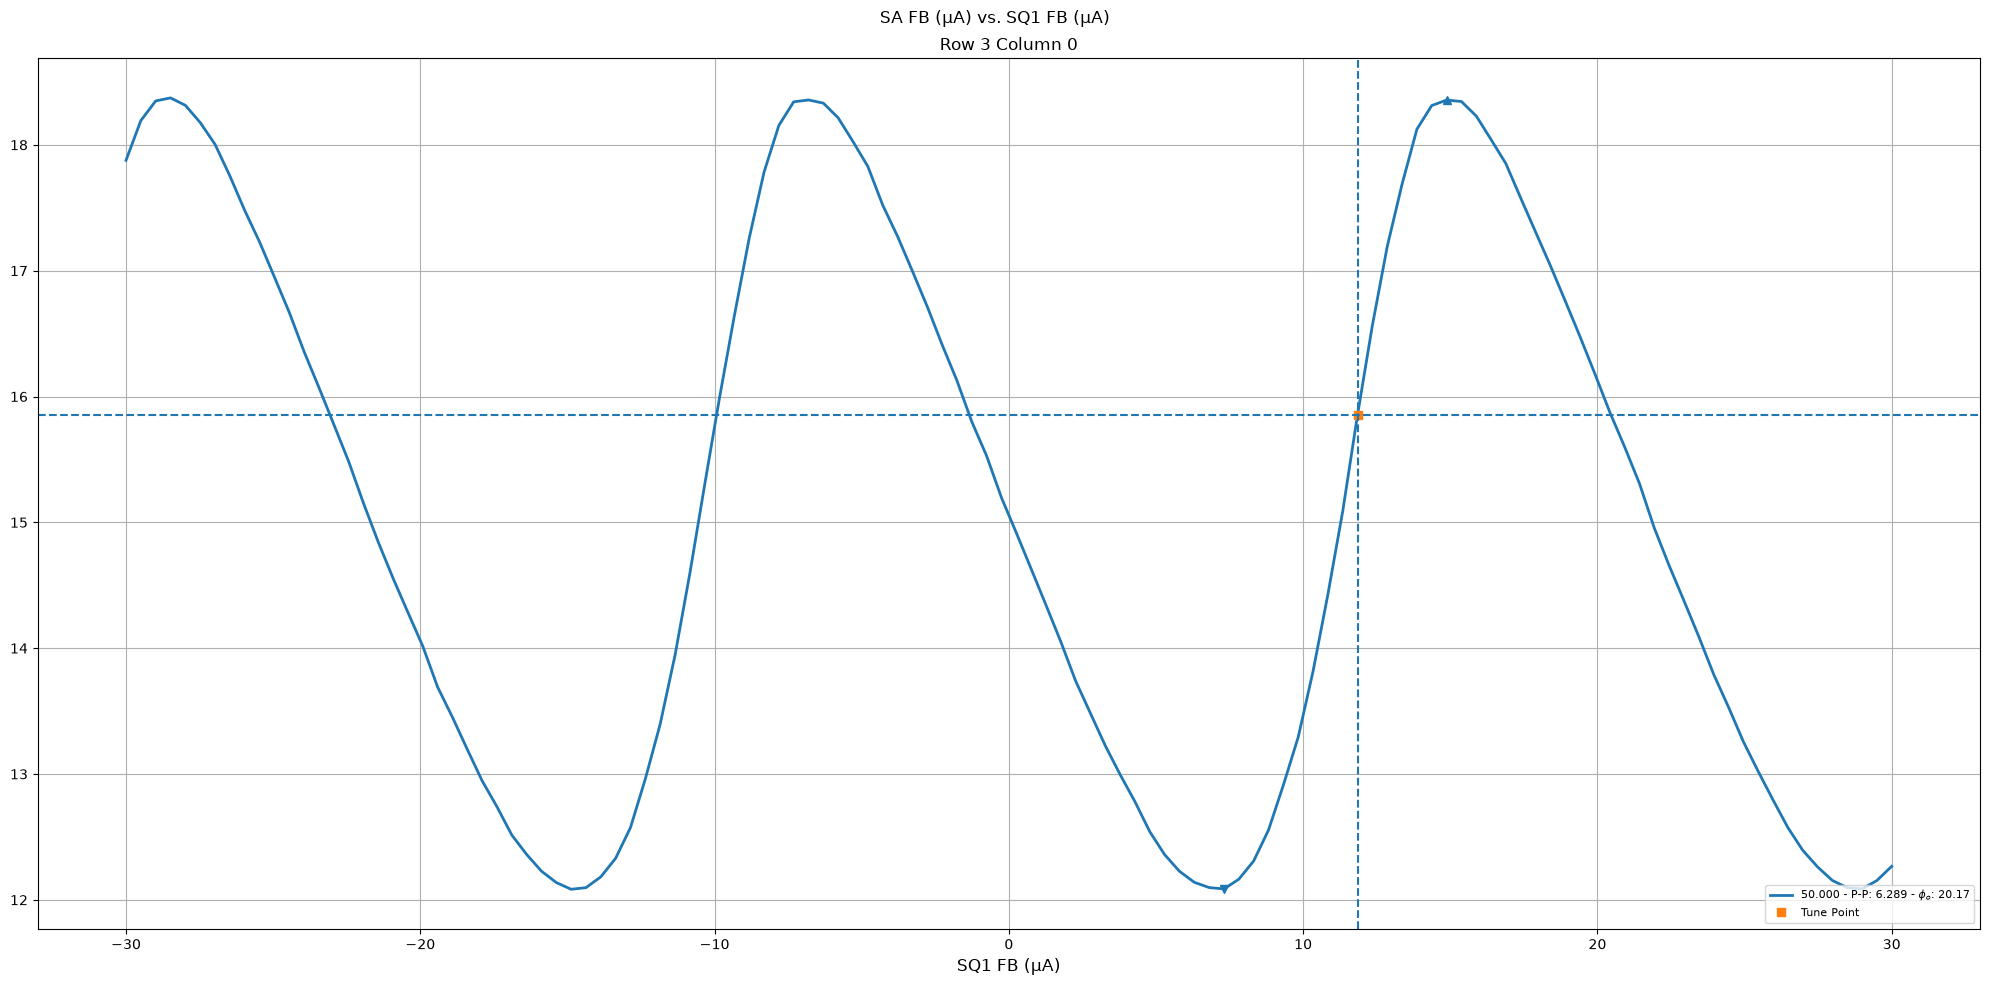

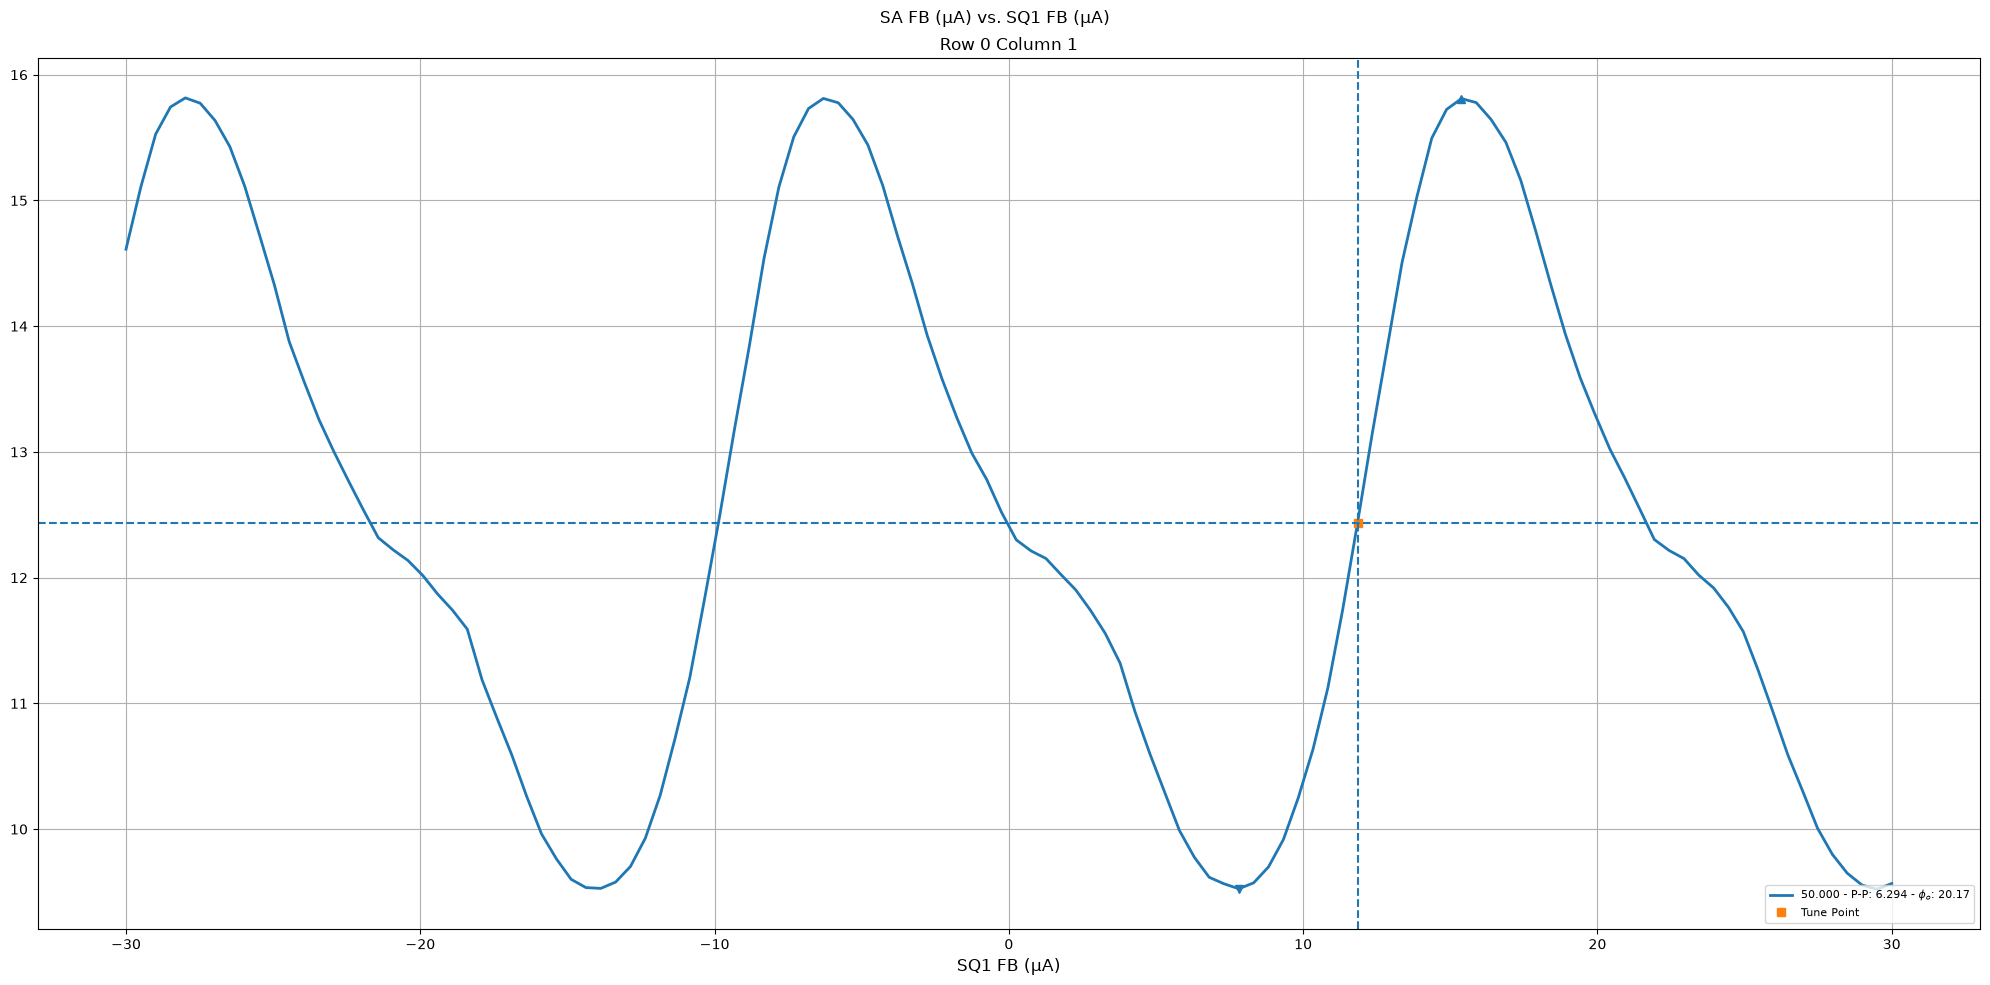

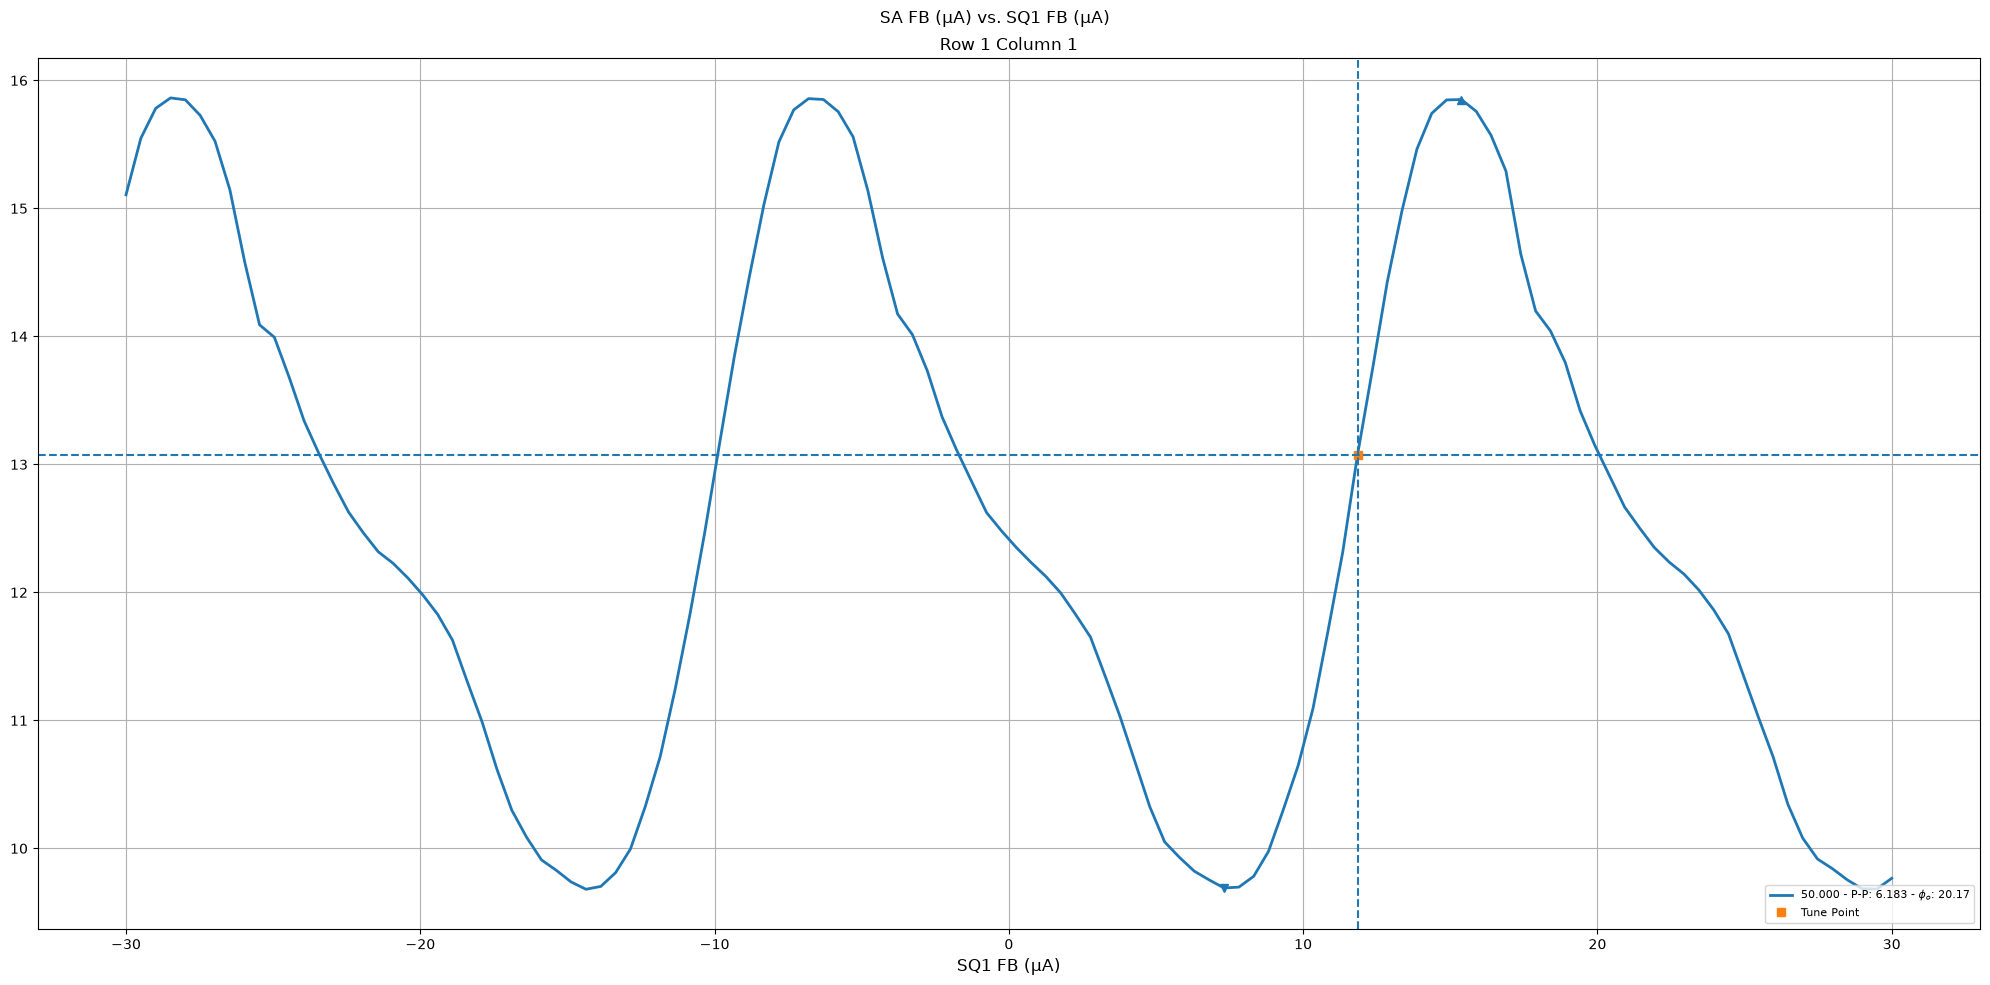

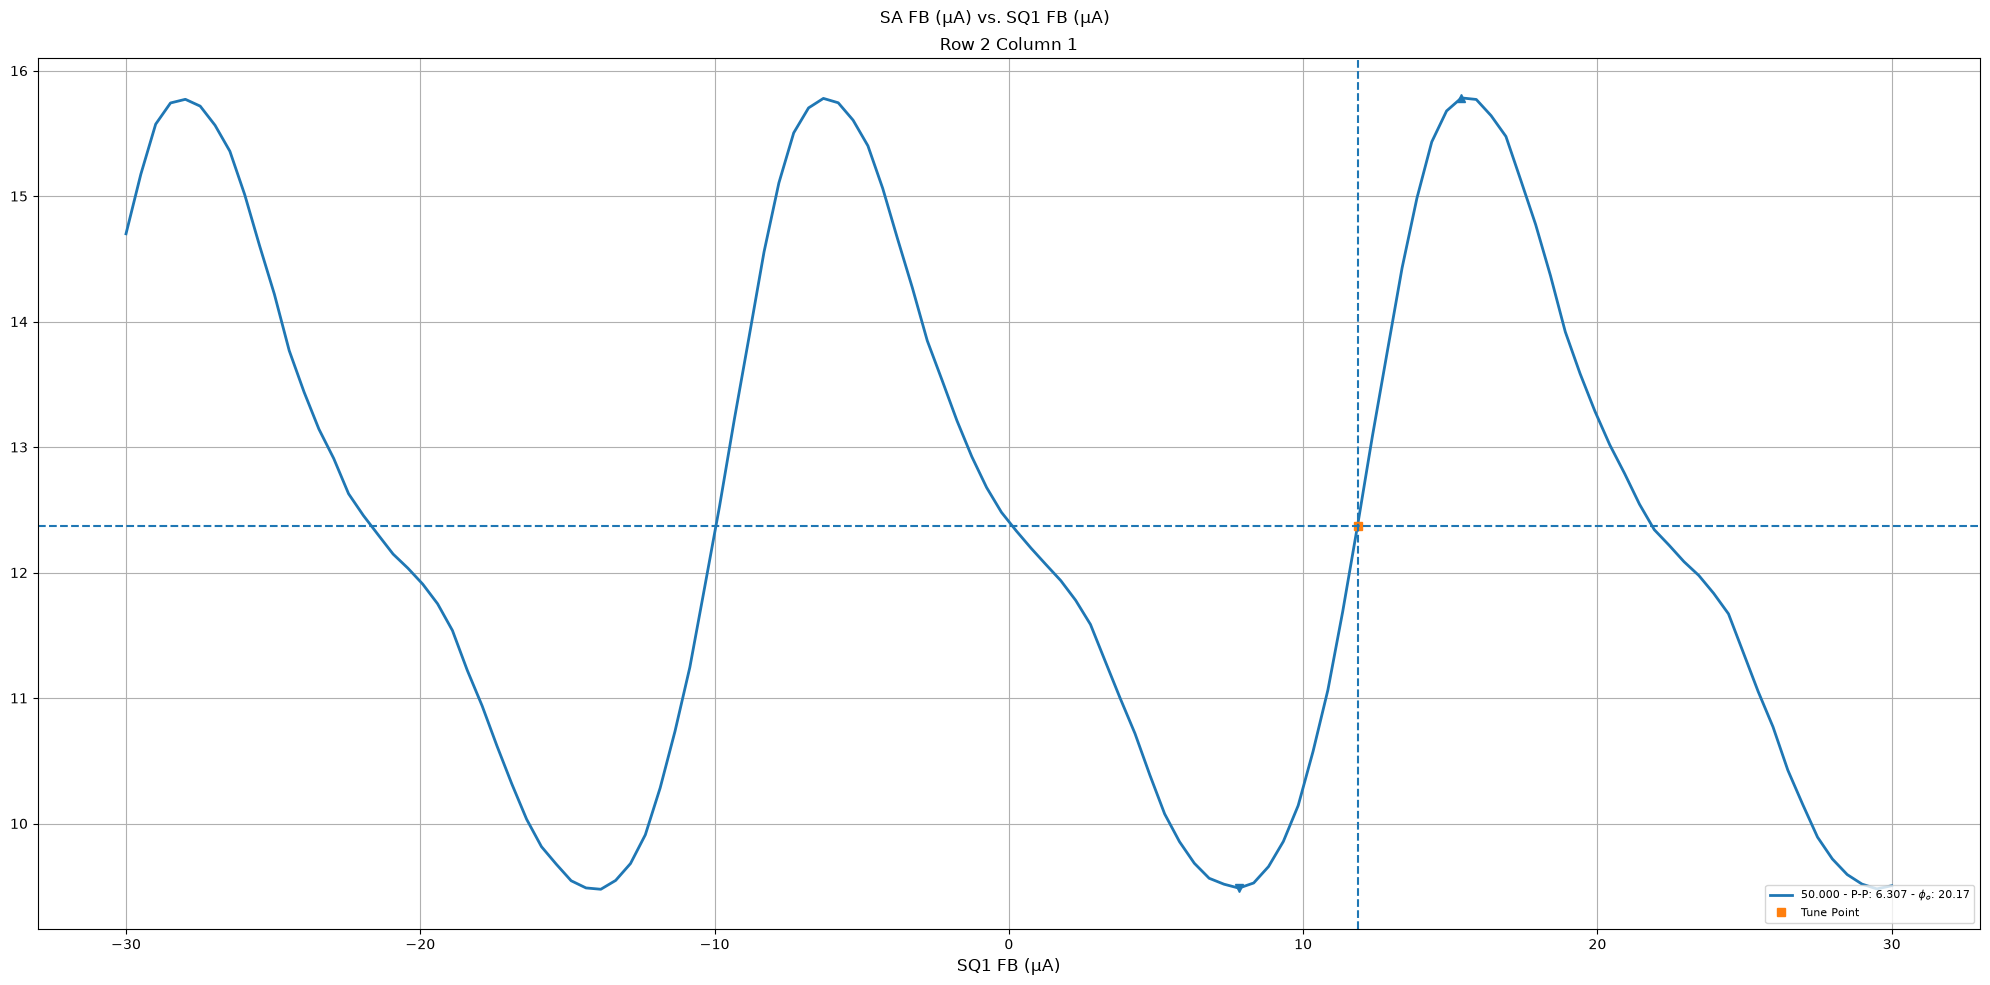

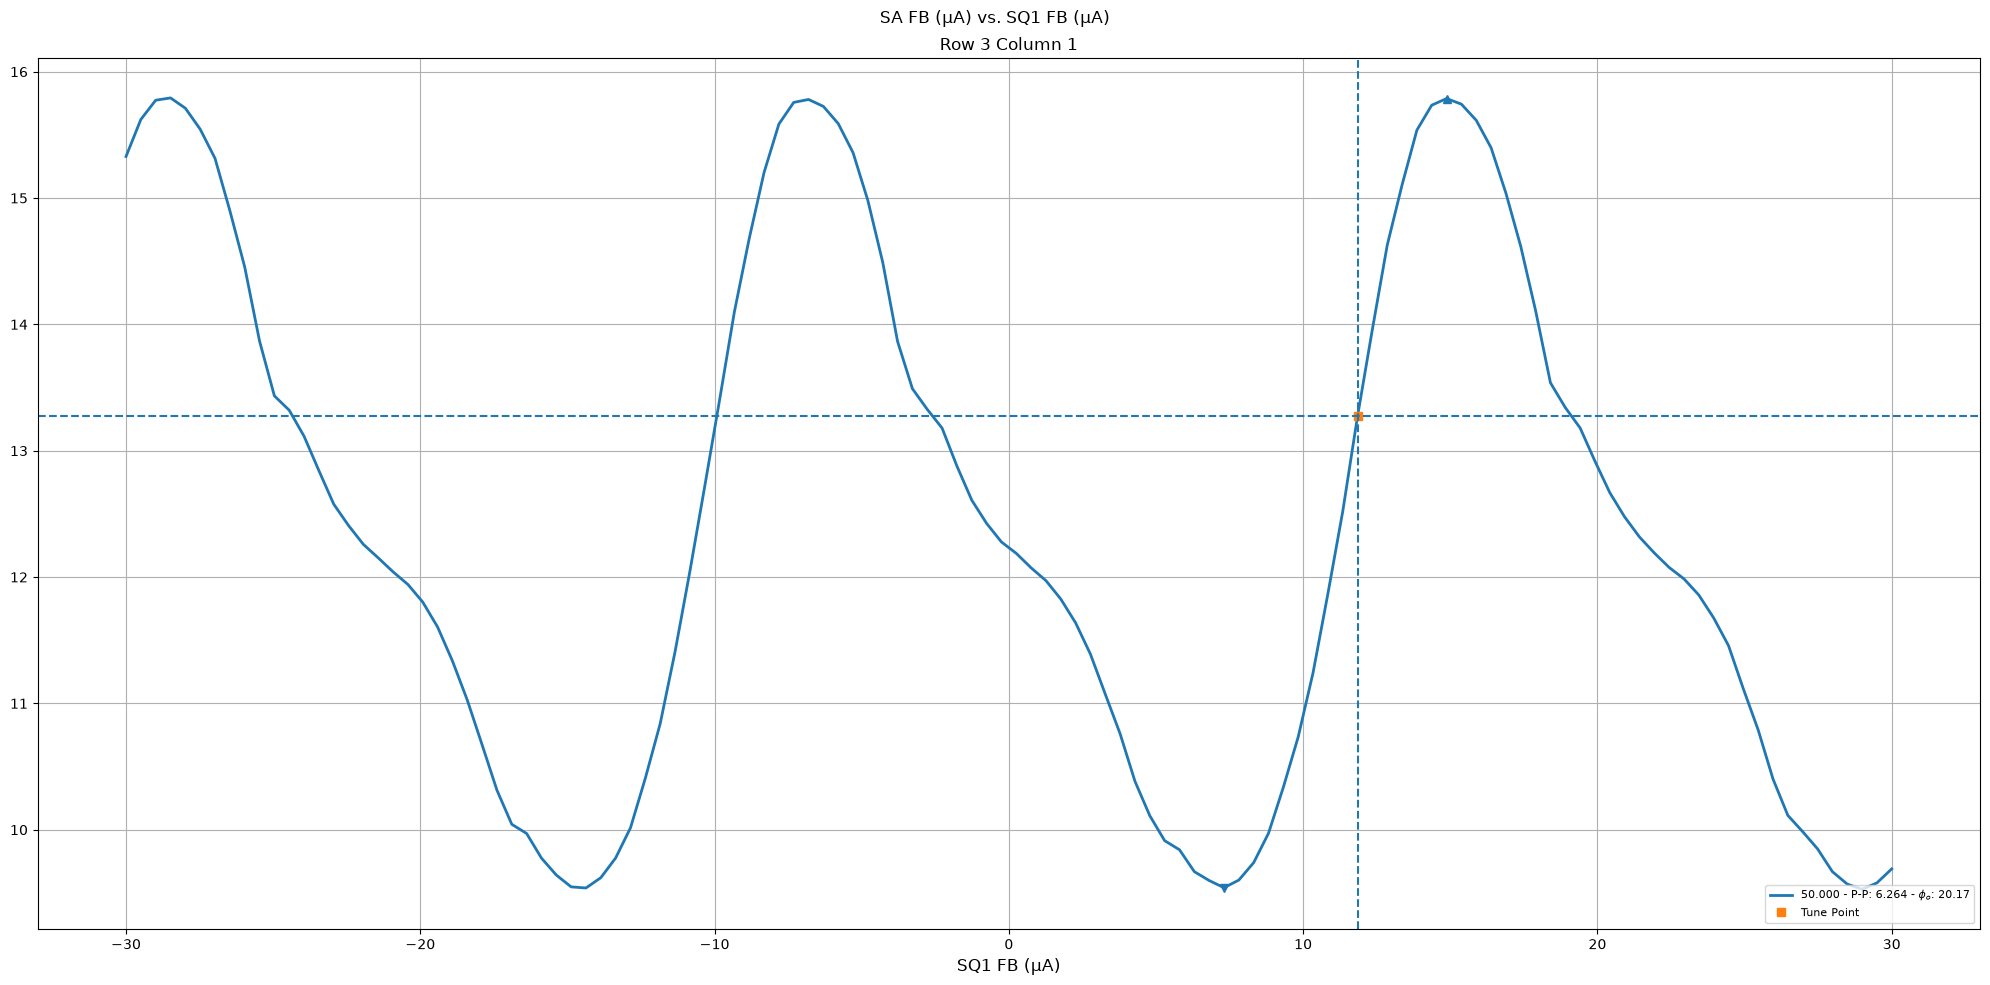

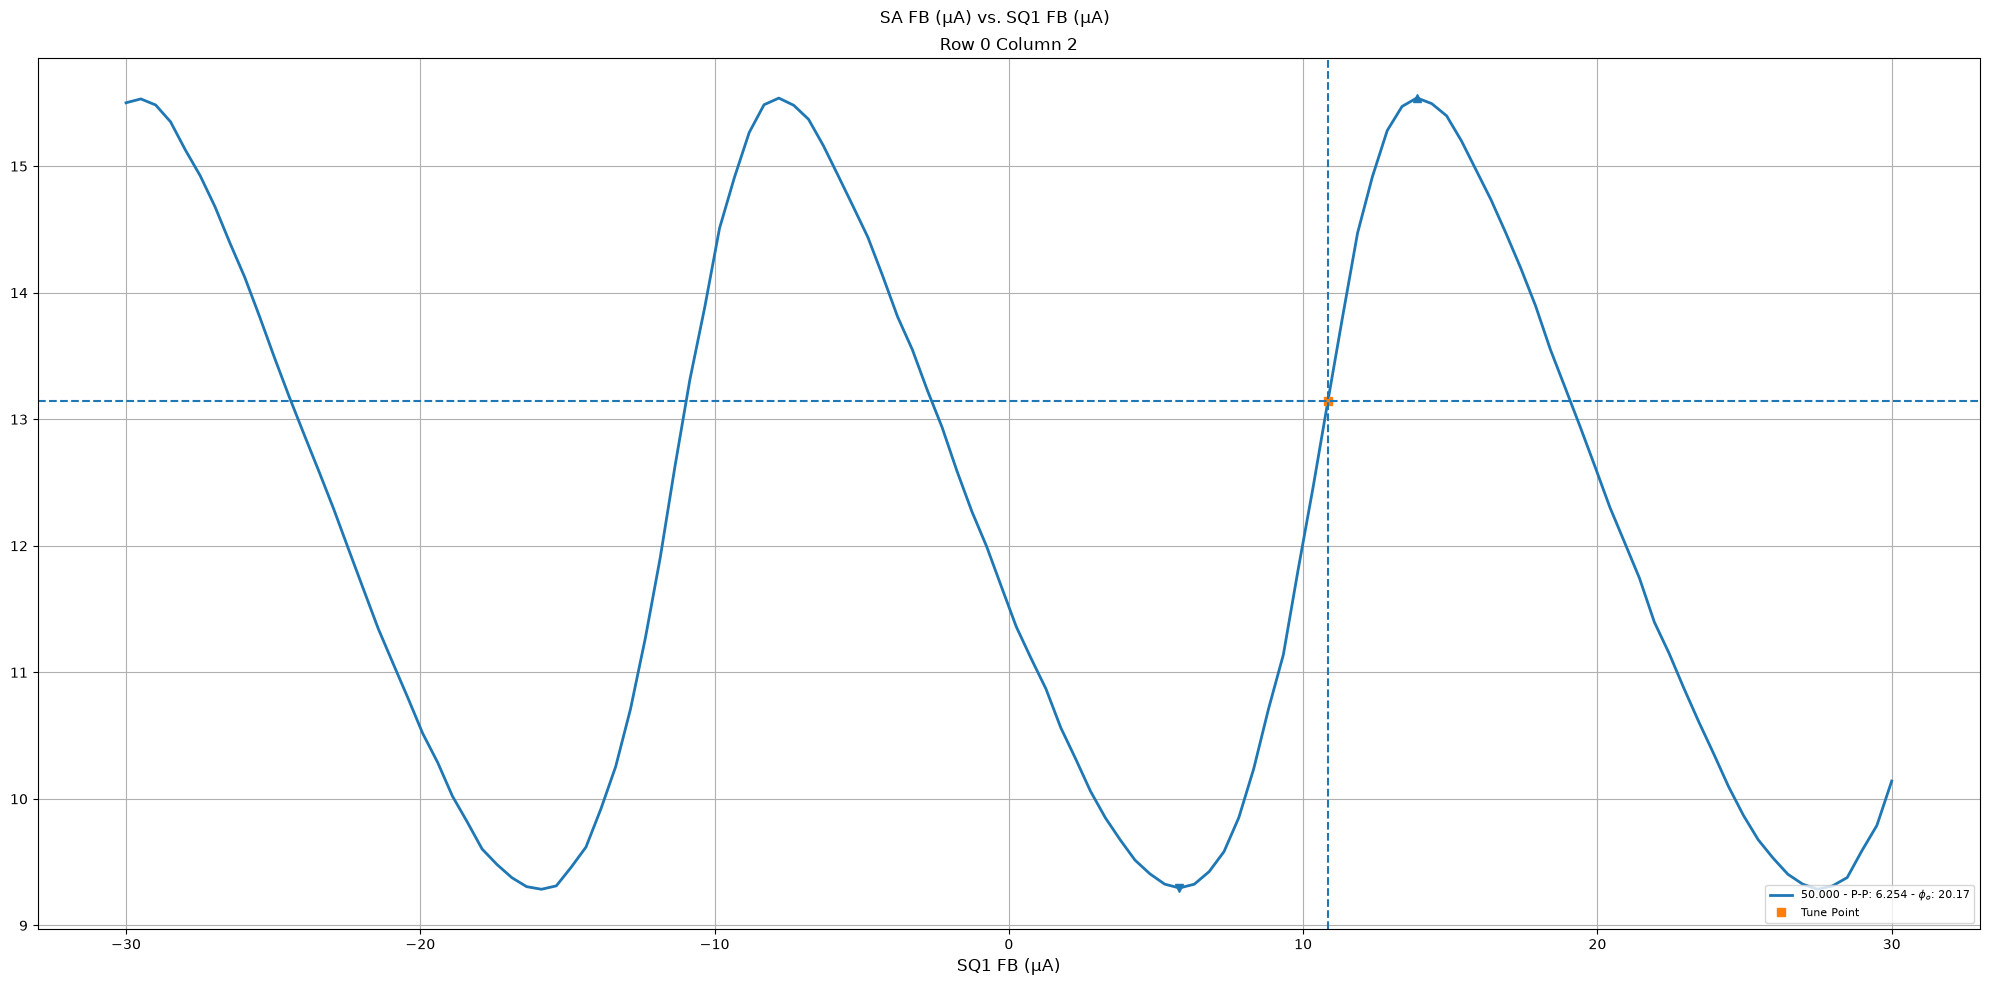

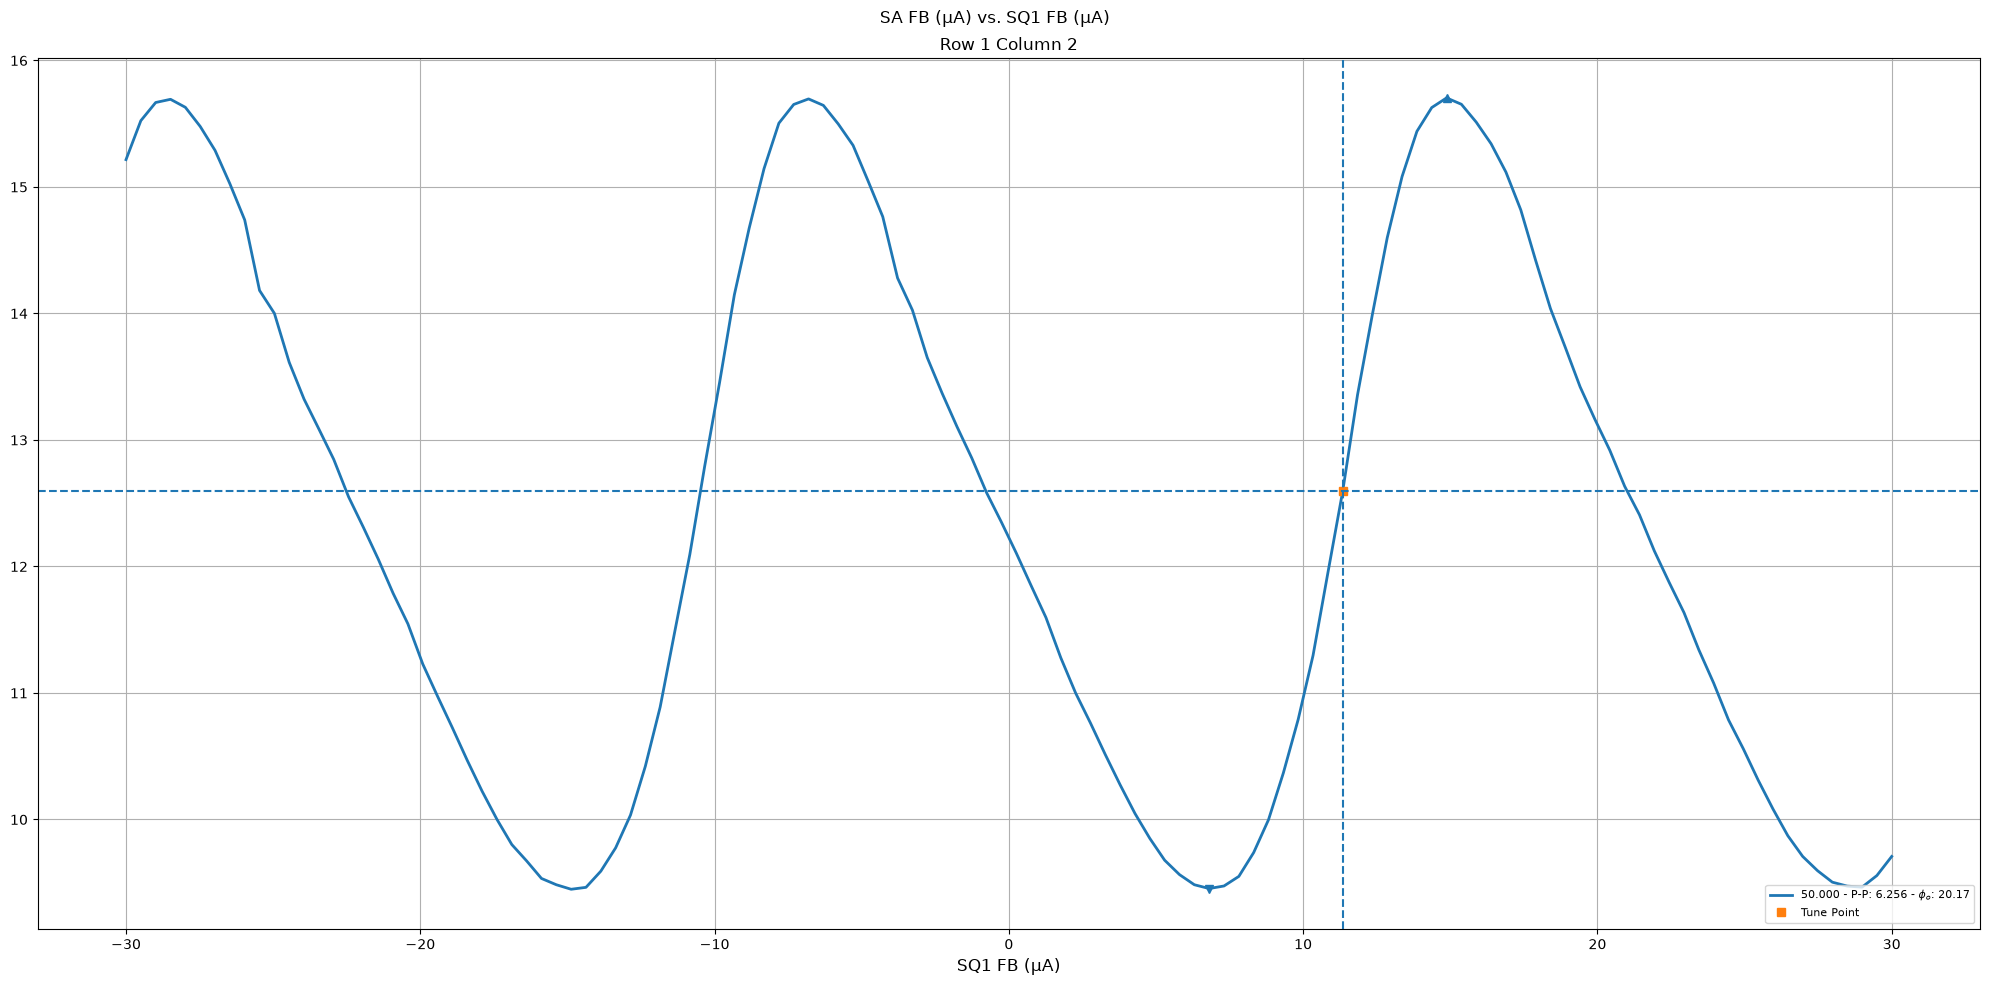

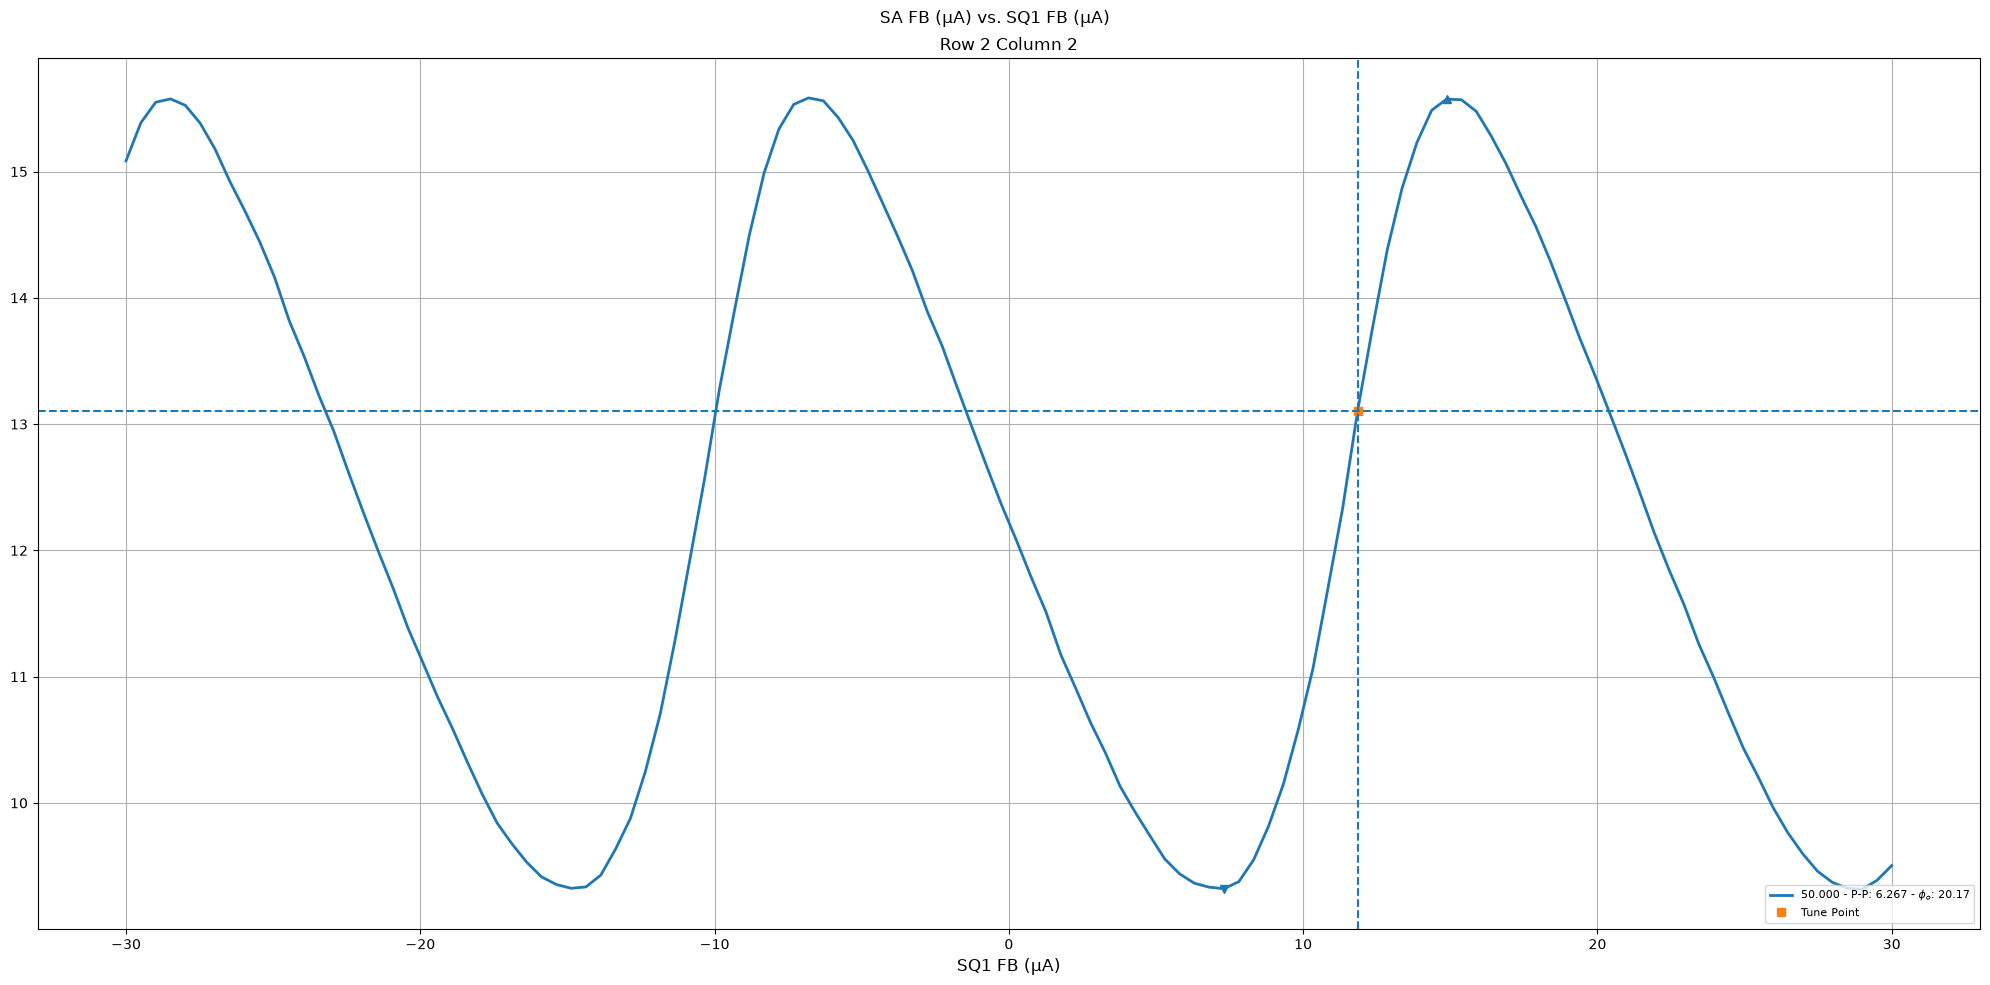

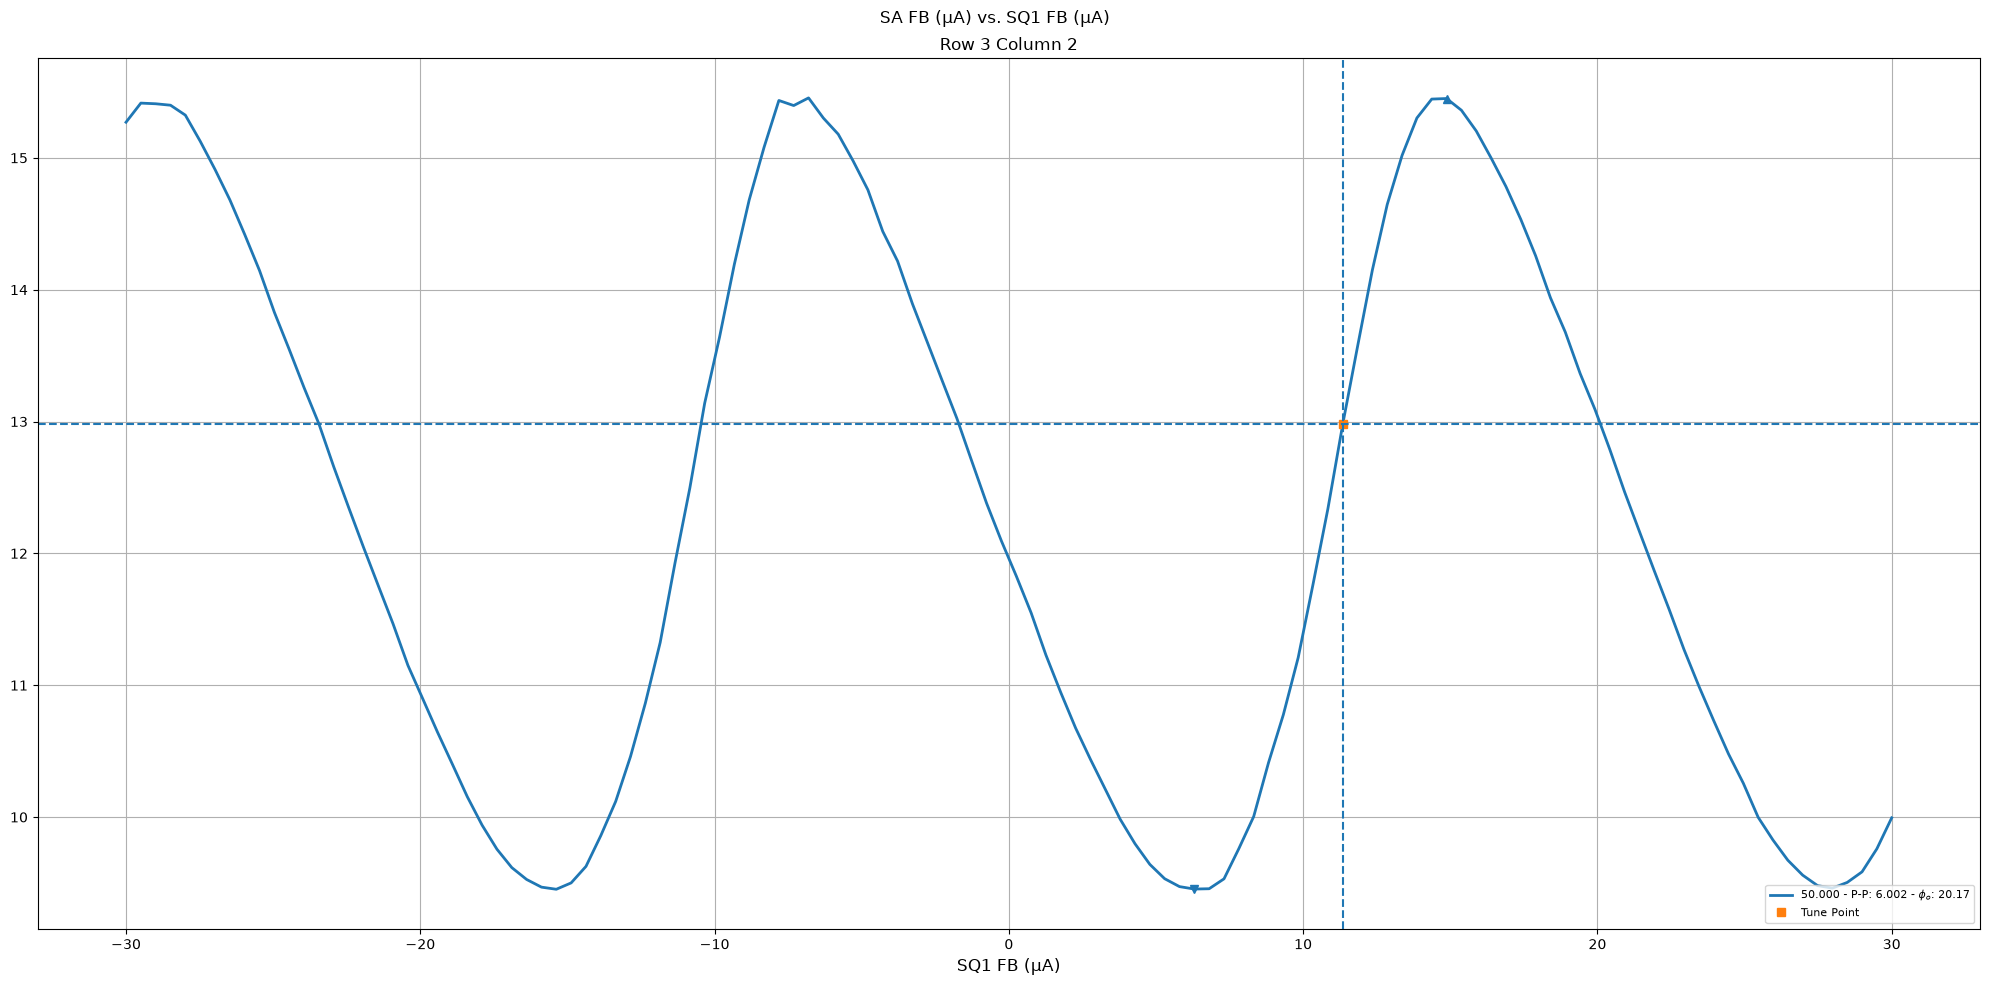

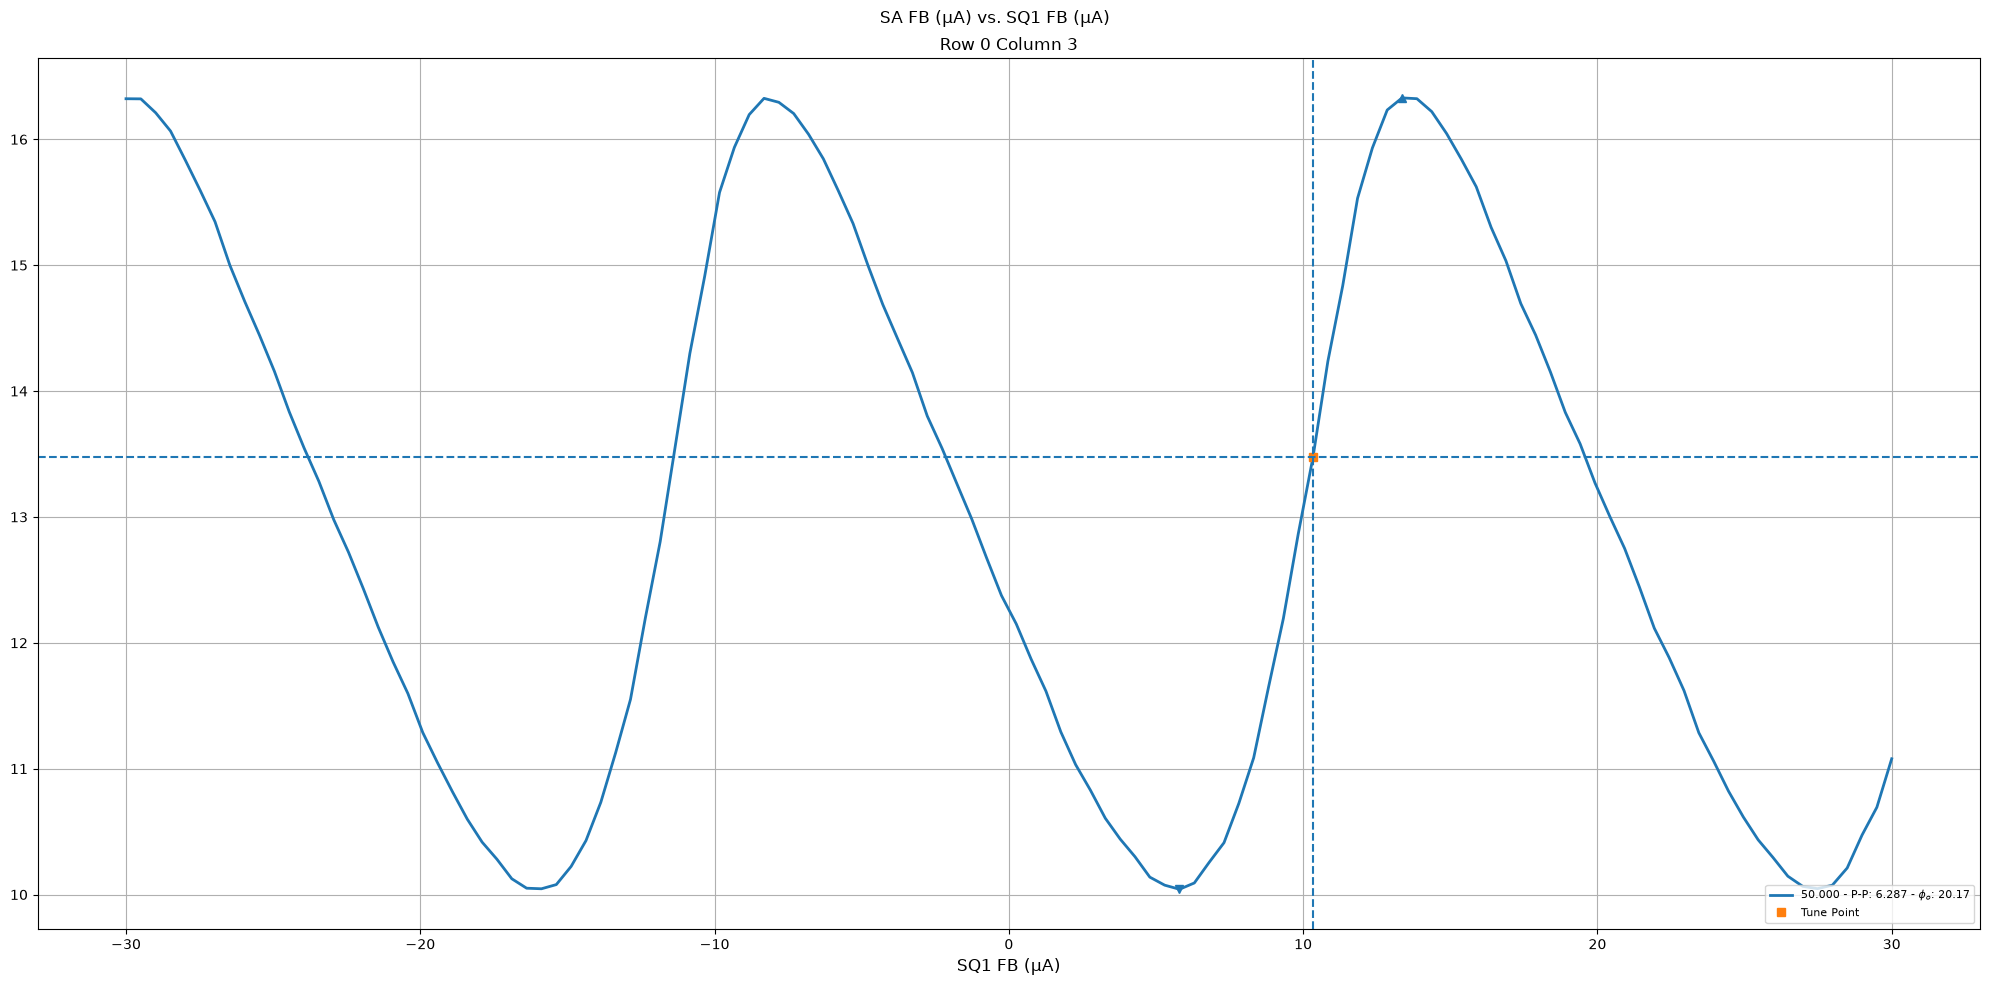

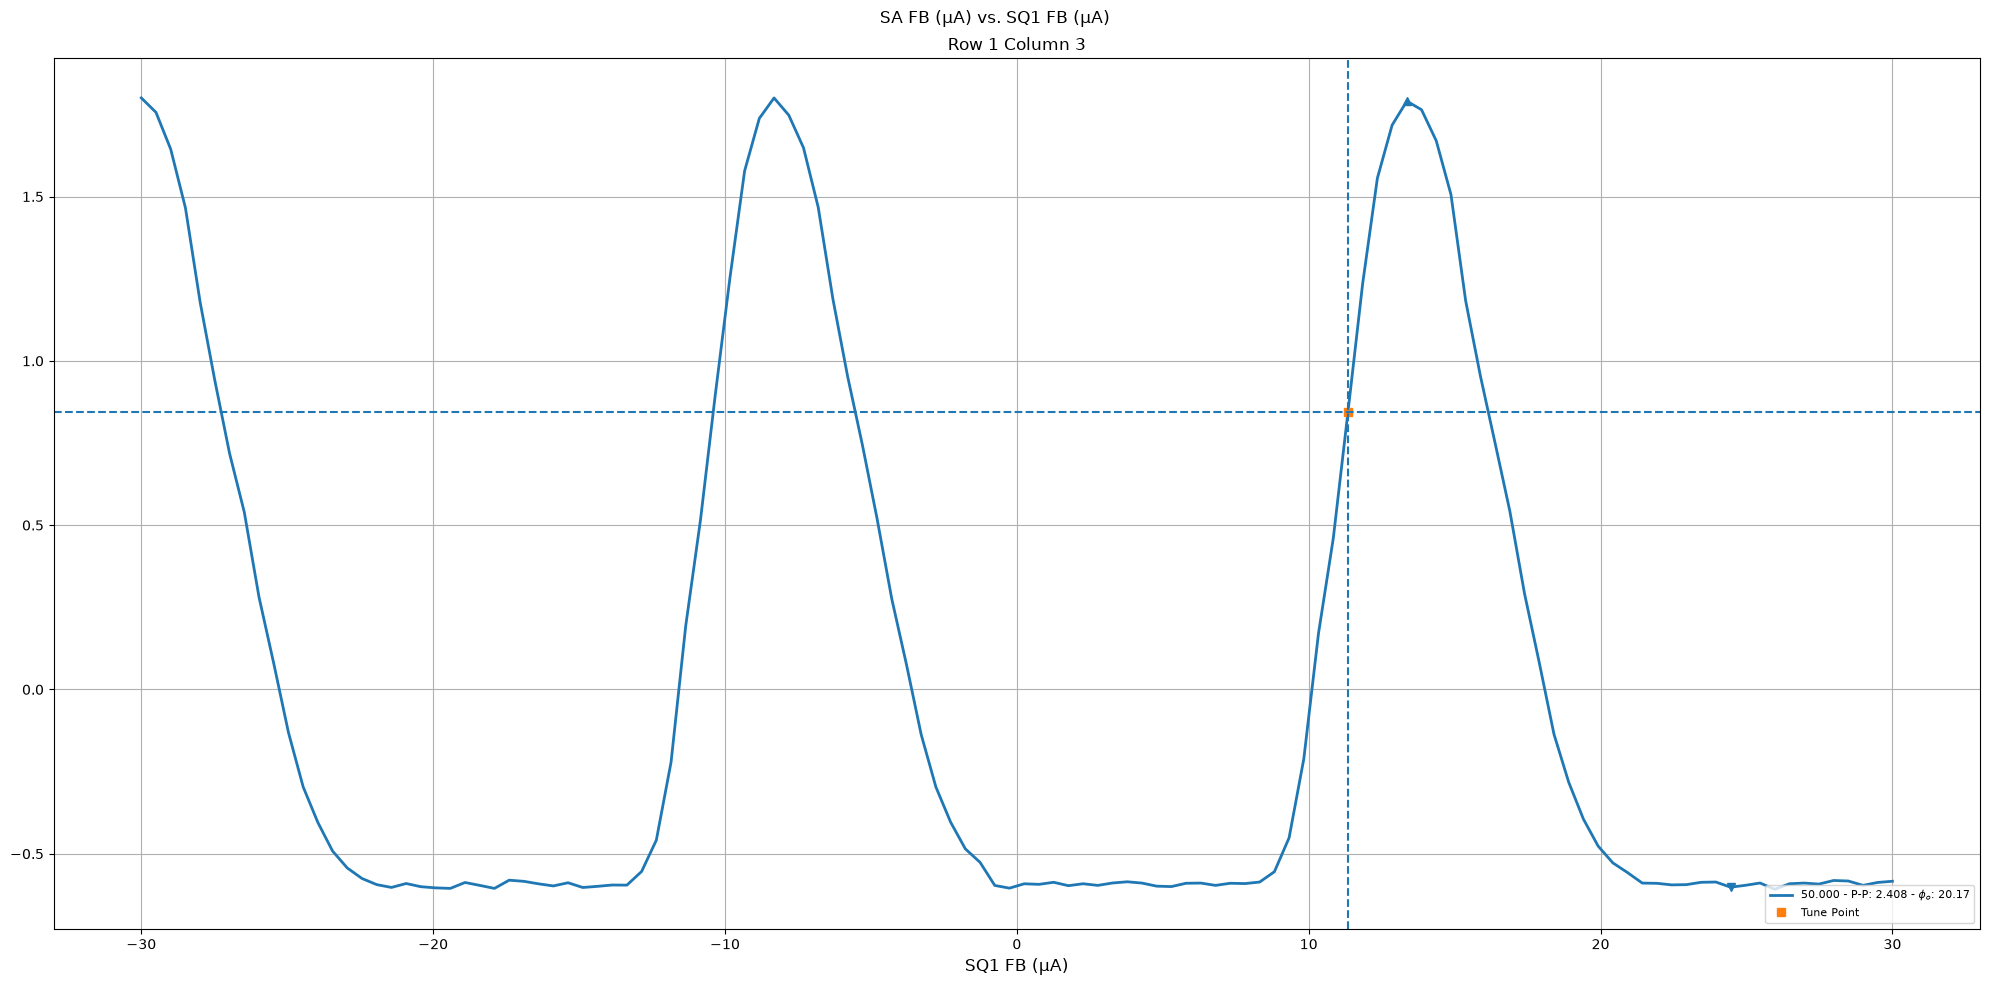

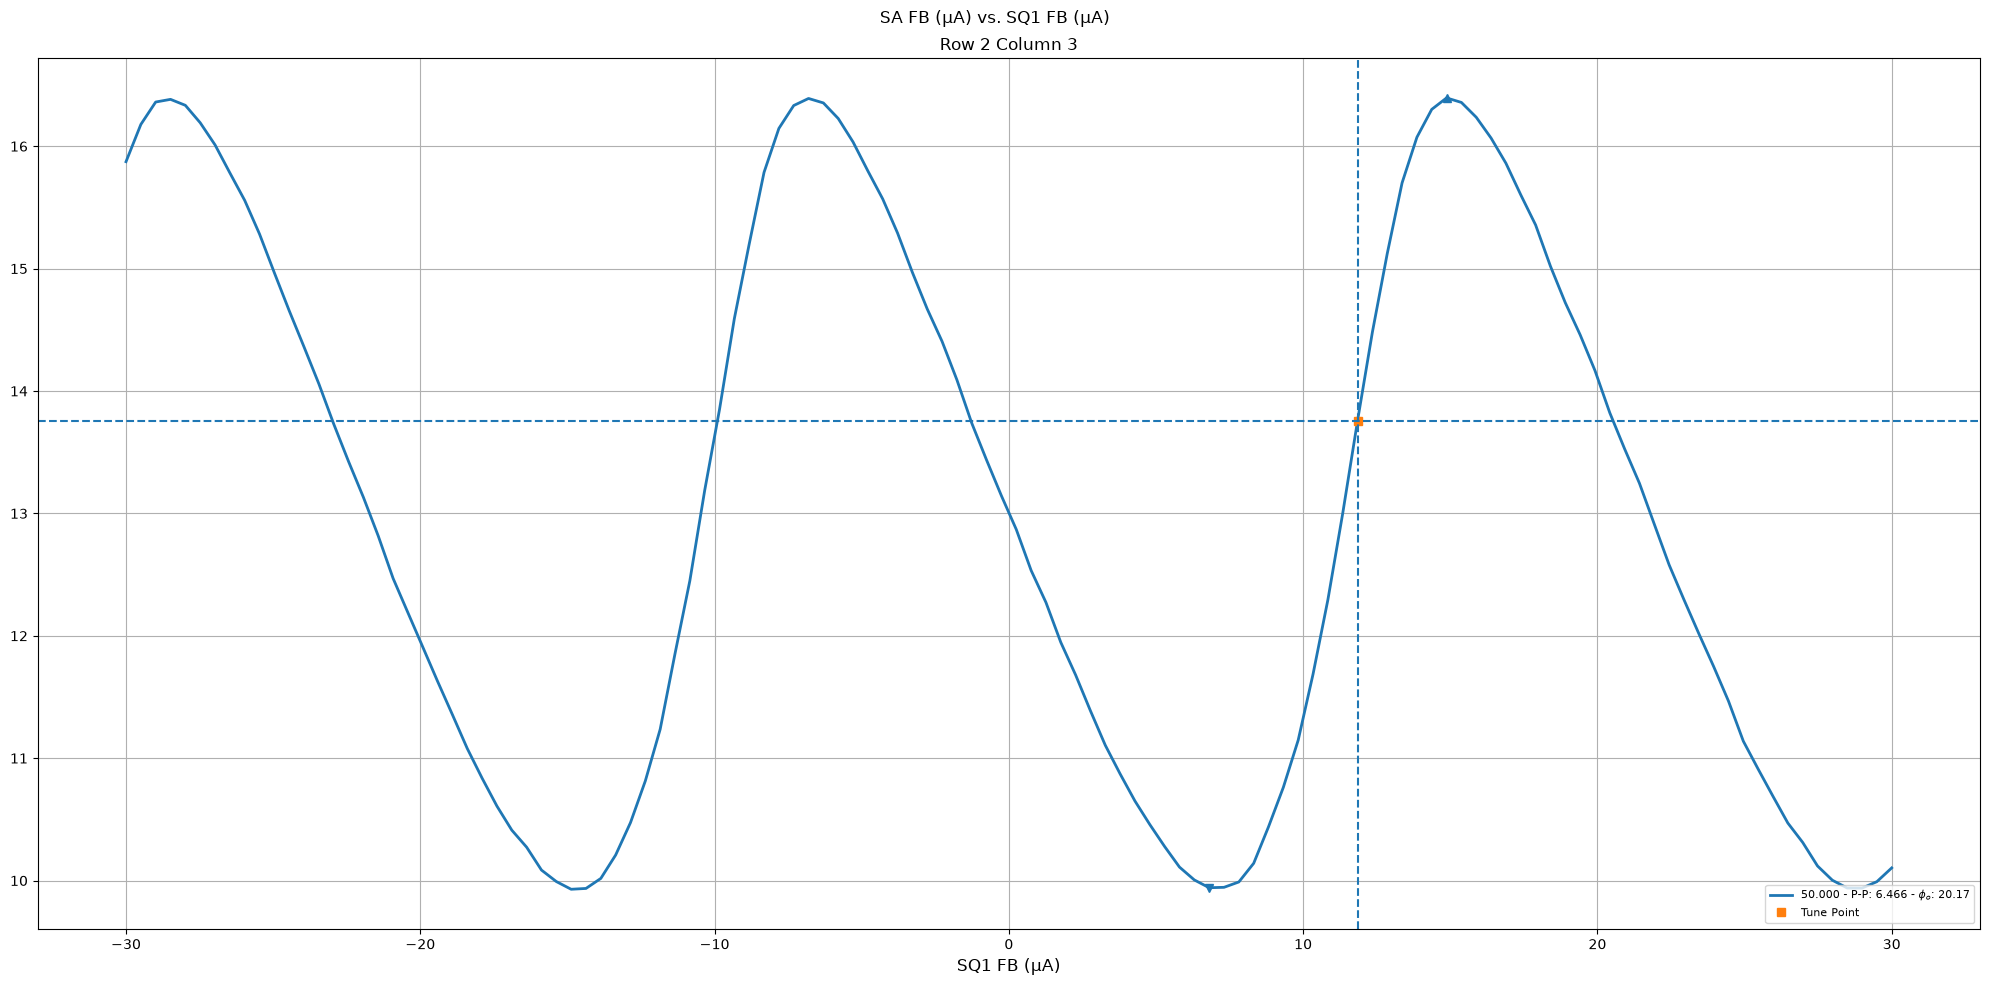

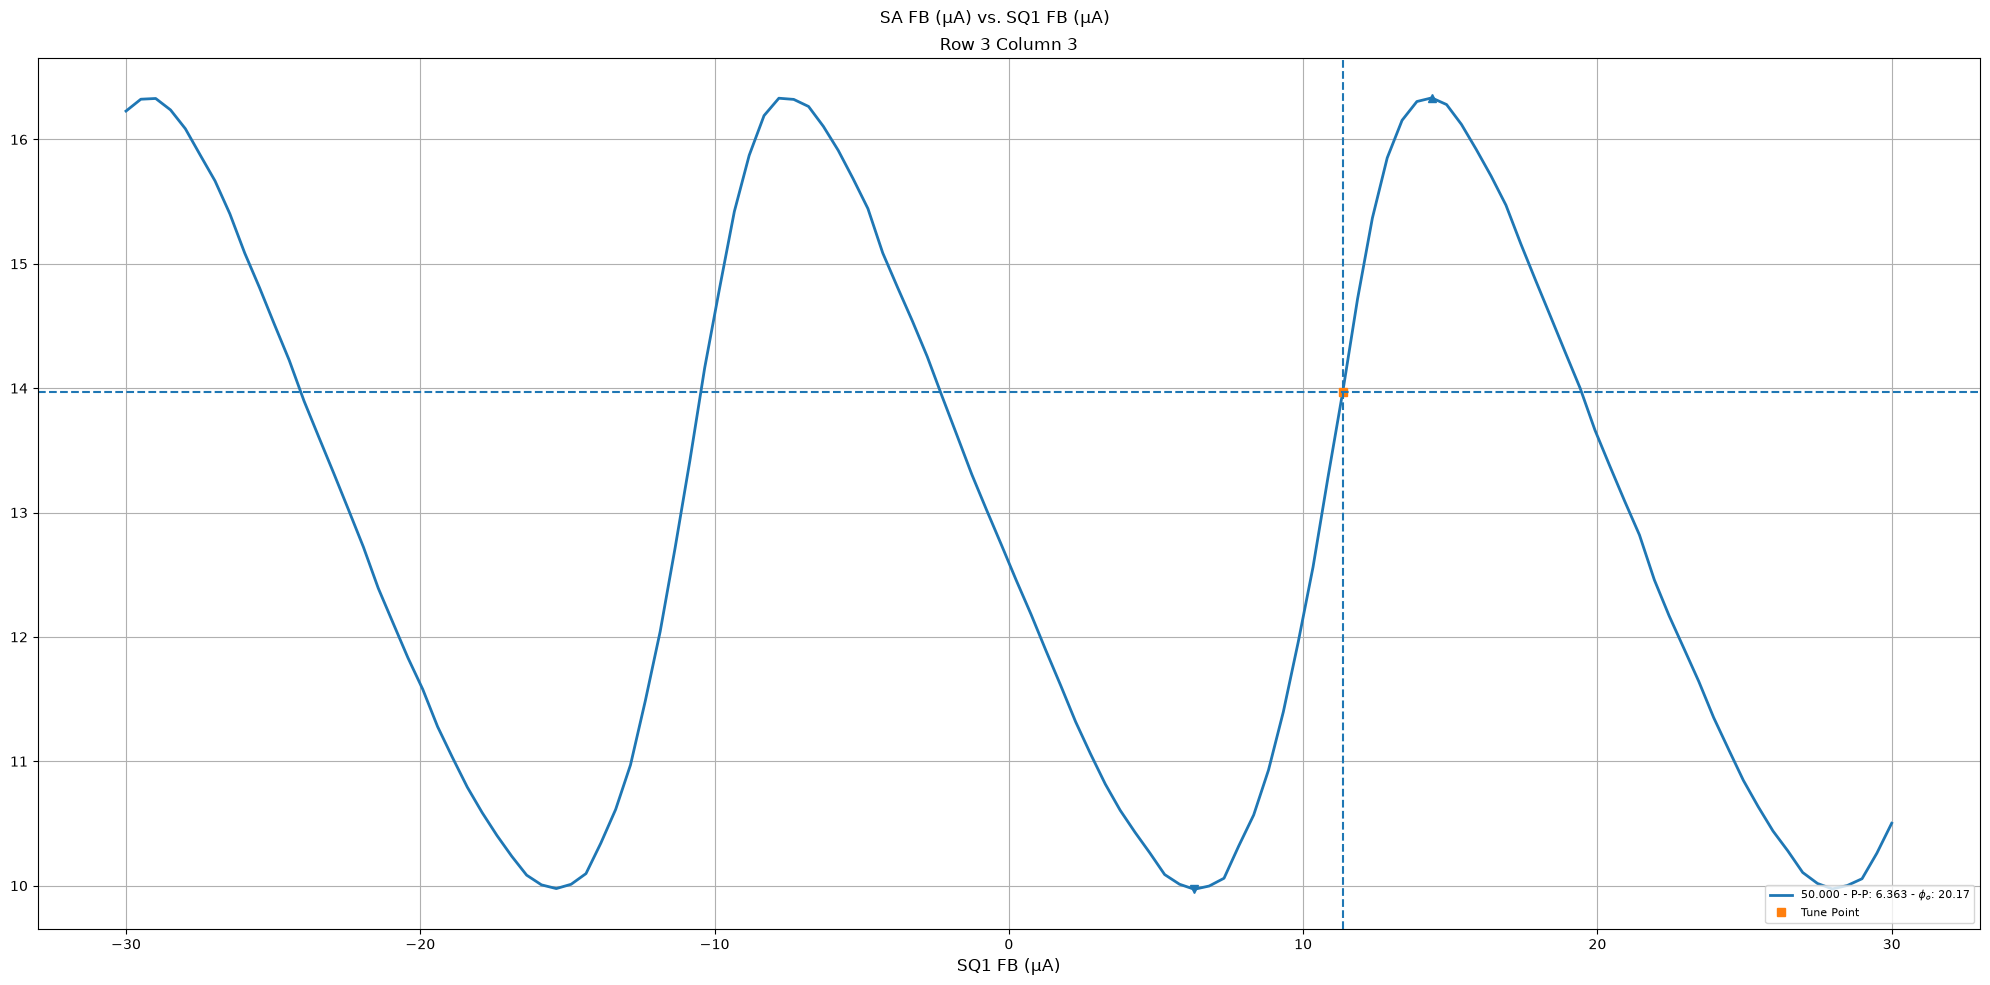

In [22]:
# Plot the SQ1 V/phi curves for a few channels:
ops.plot_sq1curves(sq1_out, cols=[c for c,e in enumerate(group.ColTuneEnable.get()) if e],
                   rows=range(len(group.RowIndexOrderList.get())))

### (Optional) save / restore the working point

`save_config` writes all RW+WO variables (a recallable config); `save_state`
adds RO (a full snapshot). Layer-scoped "just the tune point" save/restore is a
planned helper (see docs/design/muxed-run-bringup.md) — for now these broad
snapshots are what exist.

In [ ]:
# cfg = ops.save_config()                           # -> <sessiondir>/config_<ctime>.yml
# ops.load_config(cfg)                              # restore later

## C. Run settings + acquire

`setup_mux` configures the coordinator timing (row period + sample window),
puts the row DACs in timing mode, and enables SQ1 PID for the active columns.
Then take a timed streaming acquisition.

In [24]:
#Now let's get the results, showing the plot and setting the relevant values
cb = r.Group.HardwareGroup.ColumnBoard[0]
sq1TuneOutput=group.Sq1TuneProcess.Sq1TuneOutput.value()
for col,enabled in enumerate(r.Group.ColTuneEnable.get()):
    if enabled:
        for row in range(len(r.Group.RowIndexOrderList.get())):
            # Get SQ1 lock point
            print(f"c{col}r{row} : FittedSq1Bias = {sq1TuneOutput[row][col]['biasOut']}")
            print(f"c{col}r{row} : FittedSq1Fb = {sq1TuneOutput[row][col]['xOut']}")
            print(f"c{col}r{row} : FittedSaFb = {sq1TuneOutput[row][col]['yOut']}")

            # Set SQ1 lock point
            cb.SQ1Bias.Column[col].Current_[r.Group.RowIndexOrderList.get()[row]].set(sq1TuneOutput[row][col]['biasOut'])
            cb.SQ1Fb.Column[col].Current_[r.Group.RowIndexOrderList.get()[row]].set(sq1TuneOutput[row][col]['xOut'])
            cb.SAFb.Column[col].Current_[r.Group.RowIndexOrderList.get()[row]].set(sq1TuneOutput[row][col]['yOut'])

c0r0 : FittedSq1Bias = 50.0
c0r0 : FittedSq1Fb = 11.344537815126046
c0r0 : FittedSaFb = 15.507004864444996
c0r1 : FittedSq1Bias = 50.0
c0r1 : FittedSq1Fb = 11.84873949579832
c0r1 : FittedSaFb = 15.778289269646136
c0r2 : FittedSq1Bias = 50.0
c0r2 : FittedSq1Fb = 11.84873949579832
c0r2 : FittedSaFb = 15.847188462902631
c0r3 : FittedSq1Bias = 50.0
c0r3 : FittedSq1Fb = 11.84873949579832
c0r3 : FittedSaFb = 15.854691675809333
c1r0 : FittedSq1Bias = 50.0
c1r0 : FittedSq1Fb = 11.84873949579832
c1r0 : FittedSaFb = 12.435928274937051
c1r1 : FittedSq1Bias = 50.0
c1r1 : FittedSq1Fb = 11.84873949579832
c1r1 : FittedSaFb = 13.075909289628948
c1r2 : FittedSq1Bias = 50.0
c1r2 : FittedSq1Fb = 11.84873949579832
c1r2 : FittedSaFb = 12.373319700188443
c1r3 : FittedSq1Bias = 50.0
c1r3 : FittedSq1Fb = 11.84873949579832
c1r3 : FittedSaFb = 13.273028400618655
c2r0 : FittedSq1Bias = 50.0
c2r0 : FittedSq1Fb = 10.840336134453779
c2r0 : FittedSaFb = 13.142616016958376
c2r1 : FittedSq1Bias = 50.0
c2r1 : FittedSq1

In [ ]:
p_val = []
i_val = []
for col in range(len(group.ColTuneEnable.get())):
    cb.DataPath.AdcDsp[col].PidDebugEnable.set(False)
    p_val.append(cb.DataPath.AdcDsp[col].P_Coef)
    i_val.append(cb.DataPath.AdcDsp[col].I_Coef)

for col in [col for col,en in enumerate(group.ColTuneEnable.get()) if en]:
    #if col_list[col]:
    i_val[col].set(0.0)
    p_val[col].set(-0.0003*2.)

In [31]:
ops.setup_mux(
    num_pts=512,              # row period in ADC cycles (visit rate = 125 MHz / num_pts / nrows)
    sample_end_offset=100,
    sample_num=25,
    enable_pid=True,
    
)
#num_pts=2048, sample_end_offset=100, sample_num=250,
#                  strobe=False, enable_pid=True, enable_pid_debug=False
data_file = ops.take_data(acq_time_sec=10.0)        # opens DataWriter, acquires, closes
print("wrote", data_file)

Enabling PID for column 0
Enabling PID for column 1
Enabling PID for column 2
Enabling PID for column 3
Open file /sdf/group/faders/users/bareese/projects/warm-tdm-cleanup/software/data/20260911/1789156819/data_20260911_150347.dat
Acquire data for 10.0 sec ...
wrote /sdf/group/faders/users/bareese/projects/warm-tdm-cleanup/software/data/20260911/1789156819/data_20260911_150347.dat


## Analyze

`plot_stream_data` reads the readout stream (channel 9) from the `.dat` and
plots time-domain + ASD for the requested channels. Calibration (sample rate,
SQ1FB→pA) is derived from the file's embedded config automatically.

16217 samples on all plotted channels.


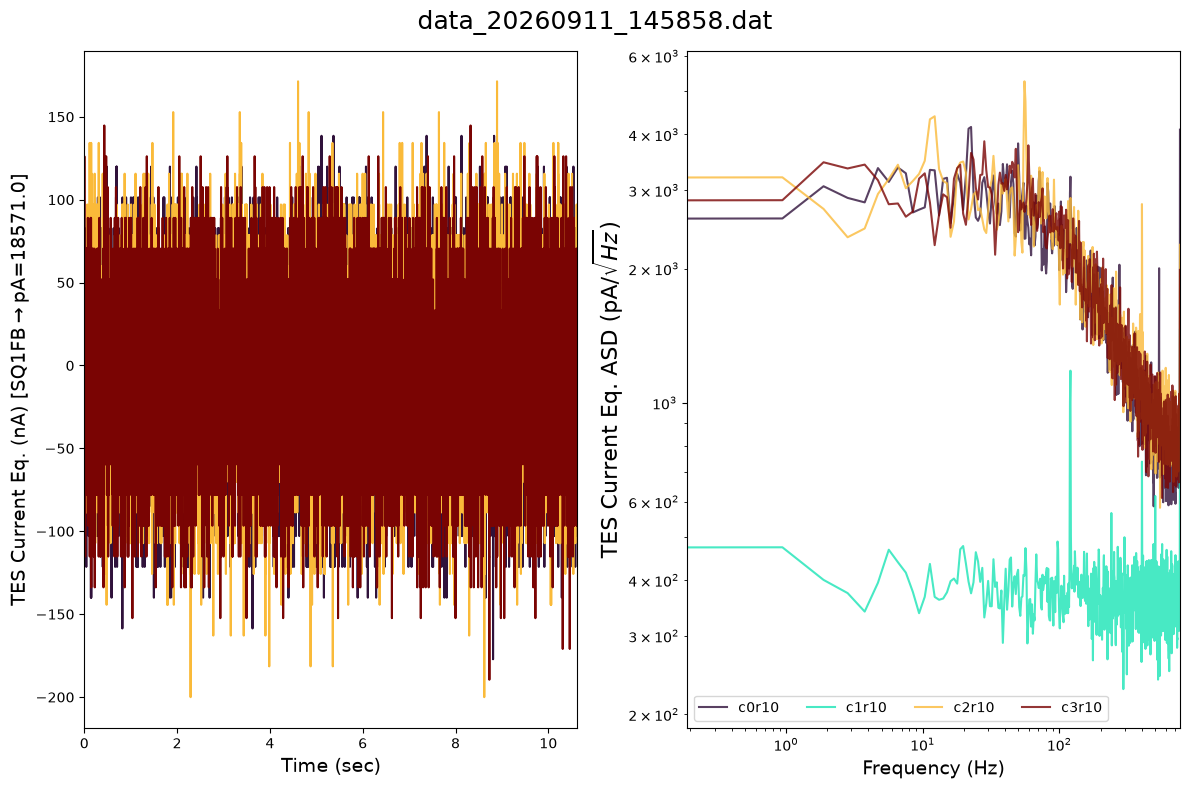

In [29]:
res = ops.plot_stream_data("c*r10", stream_data_id=data_file)   # path is first-class
# analyze a pair with a noise-model fit:
# ops.analyze_pair("c0r0", "c0r1", stream_data_id=data_file, do_fit=True)

### (Debug) raw waveforms and PID-debug

Raw ADC captures and the per-(col,row) PID-debug stream are debugging aids, not
part of normal operation.

In [32]:
raw_idx = ops.multi_raw(col=0, nraw=10)           # .npy captures -> index file
freqs, mean_asd, rms = ops.get_mean_raw_asd(col=0, idxpath=raw_idx)

# PID-debug (only populated if the run had AdcDsp PidDebugEnable set):
ops.plot_pid_debug("c*r*", field="accumError", pid_data_id=data_file)

10 waveforms indexed to /sdf/group/faders/users/bareese/projects/warm-tdm-cleanup/software/data/20260911/1789156819/raw_1789164249/raw_1789164249.txt for column 0.


ValueError: No PID-debug channels found matching 'c*r*' (exclude=None); is field 'accumError' present and PidDebugEnable was on?

## Safe state

`stop_and_zero` is a best-effort return to baseline: it zeros the column
setpoints, ends the run, and drops to manual timing. It is **not** a hardware
interlock (a firmware bug means biases may not fully zero after MUX, and row
DACs are left untouched) — see its docstring.

In [34]:
ops.stop_and_zero()

ERROR:warm_tdm_api.operations.session._forcedac:stop_and_zero: incomplete cleanup/verification; see errors above


False

In [19]:
%matplotlib inline